# 04 — Modelado Predictivo
**Prueba Técnica · Data Scientist Jr. · Solventa**

Construcción, comparación y evaluación de modelos de clasificación para
predecir incumplimiento a 60 días (`Mora60`) en clientes de alto riesgo.

---
**Contenido**
1. Setup y carga de datos
2. Estrategia de balanceo
3. Entrenamiento de modelos
4. Búsqueda de hiperparámetros
5. Evaluación comparativa
6. Punto de corte
7. Curva KS y distribución de scores
8. Importancia de variables
9. Scorecard por decil
10. Conclusiones

## Paso 1 — Setup y carga de datos

Se cargan los datasets generados en el notebook 03 (Feature Engineering).
El split temporal 80/20 ya fue aplicado — `train_model.parquet` contiene
el período de entrenamiento y `test_model.parquet` el período de evaluación.

Las 8 features seleccionadas son aquellas con **IV ≥ 0.005** según la
validación post-FE, descartando variables sin señal predictiva individual
(`woe_Genero`, `carga_total`, `es_cliente_nuevo`).

In [82]:
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter

from sklearn.pipeline          import Pipeline
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.model_selection   import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              precision_recall_curve, f1_score,
                              precision_score, recall_score,
                              ConfusionMatrixDisplay)
from imblearn.over_sampling    import SMOTE
from imblearn.pipeline         import Pipeline as ImbPipeline
import xgboost  as xgb
import lightgbm as lgb



warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

# ── Paleta visual ─────────────────────────────────────────────────────────
COLOR_BUENO = "#4C72B0"
COLOR_MALO  = "#C44E52"
COLOR_NEU   = "#2A9D8F"
COLORES_MOD = {"LR": "#F0A500", "RF": COLOR_BUENO,
               "XGB": COLOR_NEU, "LGBM": COLOR_MALO}

plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#F7F7F7",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
})

print("✓ Librerías cargadas")

✓ Librerías cargadas


In [38]:
# ── Carga de datos ────────────────────────────────────────────────────────
DIR_ART   = Path("artefactos")

df_train  = pd.read_parquet(DIR_ART / "train_model.parquet")
df_test   = pd.read_parquet(DIR_ART / "test_model.parquet")

TARGET = "Mora60"

# 9 features seleccionadas por IV ≥ 0.005 en validación post-FE
# Se excluyen: woe_Genero (IV=0.000), carga_total (IV=0.001),
#              es_cliente_nuevo (IV=0.000)
FEATURES = [
    #"MoraMax_UltimoSemestre",   # IV=12.73  — Fuerte
    "log_tiempo_sistema",       # IV=0.103 — Moderado
    "PORCEND",                  # IV=0.103 — Moderado
    "log_tiempo_cliente",       # IV=0.087 — Débil
    "woe_nivel_academico_agrup",# IV=0.053 — Débil
    "Edad",                     # IV=0.020 — Débil
    "TiempoActividadAnios",     # IV=0.017 — Débil
    "capacidad_pago",           # IV=0.011 — Bajo (se mantiene)
    "woe_estado_civil_agrup",   # IV=0.007 — Bajo (se mantiene)
]

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[FEATURES]
y_test  = df_test[TARGET]

print(f"Train : {X_train.shape} | Malos: {y_train.sum()} ({y_train.mean():.2%})")
print(f"Test  : {X_test.shape}  | Malos: {y_test.sum()} ({y_test.mean():.2%})")
print(f"\nFeatures ({len(FEATURES)}):")
for f in FEATURES:
    print(f"  • {f}")

Train : (3452, 8) | Malos: 412 (11.94%)
Test  : (863, 8)  | Malos: 92 (10.66%)

Features (8):
  • log_tiempo_sistema
  • PORCEND
  • log_tiempo_cliente
  • woe_nivel_academico_agrup
  • Edad
  • TiempoActividadAnios
  • capacidad_pago
  • woe_estado_civil_agrup


## Paso 2 — Estrategia de balanceo

### Contexto del desbalance

Con **11.9% de malos en train** (412 de 3,452) el desbalance es **moderado**,
no severo. Un modelo que prediga siempre "bueno" tendría 88% de accuracy
sin ningún poder discriminante real — por eso accuracy no es la métrica
de evaluación y se usa AUC-ROC y KS.

### Tres estrategias a comparar

| Estrategia | Mecanismo | Riesgo |
|---|---|---|
| **`class_weight='balanced'`** | Penaliza más los errores en la clase minoritaria ajustando los pesos internamente | Ninguno — no modifica los datos |
| **`scale_pos_weight` / `is_unbalance`** | Equivalente nativo en XGBoost y LightGBM | Ninguno |
| **SMOTE** | Genera muestras sintéticas de la clase minoritaria por interpolación | Con n=412 malos puede generar ruido; se evalúa solo en LR y RF |

### Decisión de diseño
Cada modelo se entrenará **con su estrategia de balanceo nativa** como punto
de partida. SMOTE se evaluará como variante adicional en la búsqueda de
hiperparámetros para determinar si mejora las métricas o las degrada.

In [39]:
# ── Diagnóstico del desbalance ─────────────────────────────────────────────
tasa_train = y_train.mean()
tasa_test  = y_test.mean()
ratio      = (y_train == 0).sum() / (y_train == 1).sum()

print("═"*50)
print("DIAGNÓSTICO DE DESBALANCE")
print("═"*50)
print(f"  Train — Buenos: {(y_train==0).sum():,} | Malos: {(y_train==1).sum():,}")
print(f"  Train — Tasa de default: {tasa_train:.2%}")
print(f"  Ratio buenos/malos: {ratio:.1f}:1")
print()
print(f"  Test  — Buenos: {(y_test==0).sum():,} | Malos: {(y_test==1).sum():,}")
print(f"  Test  — Tasa de default: {tasa_test:.2%}")
print()

if ratio < 4:
    print("  ✅ Desbalance leve  — class_weight suficiente")
elif ratio < 10:
    print("  ⚠️  Desbalance moderado — evaluar SMOTE como complemento")
else:
    print("  🔴 Desbalance severo — SMOTE o undersampling necesario")
print("═"*50)

══════════════════════════════════════════════════
DIAGNÓSTICO DE DESBALANCE
══════════════════════════════════════════════════
  Train — Buenos: 3,040 | Malos: 412
  Train — Tasa de default: 11.94%
  Ratio buenos/malos: 7.4:1

  Test  — Buenos: 771 | Malos: 92
  Test  — Tasa de default: 10.66%

  ⚠️  Desbalance moderado — evaluar SMOTE como complemento
══════════════════════════════════════════════════


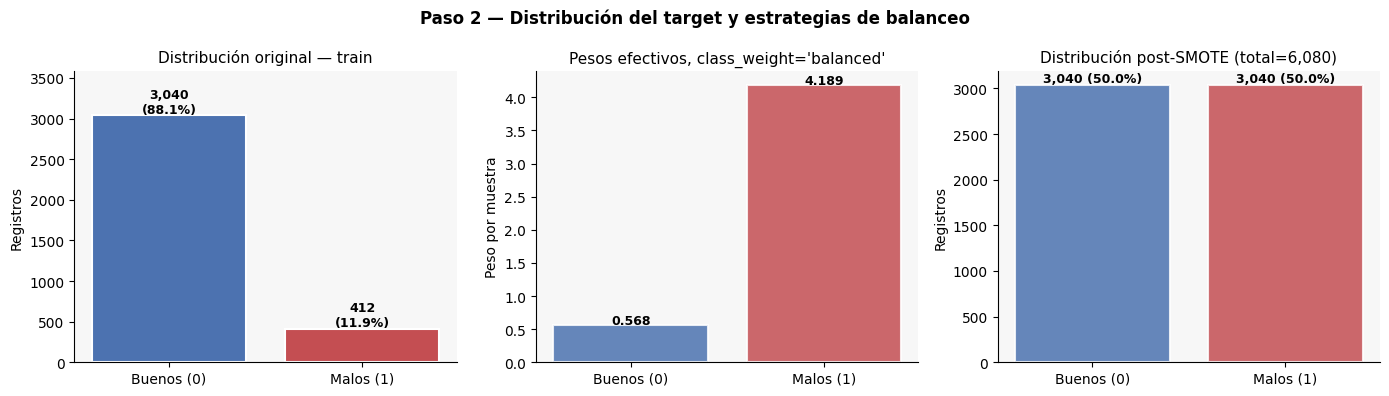


Post-SMOTE: 6,080 registros (3,040 malos sintéticos generados)
⚠️  SMOTE solo se aplicará dentro del CV en train — nunca en test


In [40]:
# ── Visualización del desbalance ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Paso 2 — Distribución del target y estrategias de balanceo",
             fontsize=12, fontweight="bold")

# Panel 1: Conteo original
axes[0].bar(["Buenos (0)", "Malos (1)"],
            [y_train.value_counts()[0], y_train.value_counts()[1]],
            color=[COLOR_BUENO, COLOR_MALO], edgecolor="white", linewidth=1.5)
axes[0].set_title("Distribución original — train")
axes[0].set_ylabel("Registros")
for i, v in enumerate([y_train.value_counts()[0], y_train.value_counts()[1]]):
    axes[0].text(i, v + 30, f"{v:,}\n({v/len(y_train):.1%})",
                 ha="center", fontsize=9, fontweight="bold")
axes[0].set_ylim(0, y_train.value_counts()[0] * 1.18)

# Panel 2: class_weight='balanced' — pesos efectivos
peso_malo  = len(y_train) / (2 * y_train.sum())
peso_bueno = len(y_train) / (2 * (y_train == 0).sum())
axes[1].bar(["Buenos (0)", "Malos (1)"],
            [peso_bueno, peso_malo],
            color=[COLOR_BUENO, COLOR_MALO], edgecolor="white",
            linewidth=1.5, alpha=0.85)
axes[1].set_title("Pesos efectivos, class_weight='balanced'")
axes[1].set_ylabel("Peso por muestra")
for i, v in enumerate([peso_bueno, peso_malo]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center",
                 fontsize=9, fontweight="bold")

# Panel 3: SMOTE — distribución resultante
smote           = SMOTE(random_state=42)
X_sm, y_sm      = smote.fit_resample(X_train, y_train)
axes[2].bar(["Buenos (0)", "Malos (1)"],
            [y_sm.value_counts()[0], y_sm.value_counts()[1]],
            color=[COLOR_BUENO, COLOR_MALO], edgecolor="white",
            linewidth=1.5, alpha=0.85)
axes[2].set_title(f"Distribución post-SMOTE (total={len(y_sm):,})")
axes[2].set_ylabel("Registros")
for i, v in enumerate([y_sm.value_counts()[0], y_sm.value_counts()[1]]):
    axes[2].text(i, v + 30, f"{v:,} ({v/len(y_sm):.1%})",
                 ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nPost-SMOTE: {X_sm.shape[0]:,} registros "
      f"({y_sm.value_counts()[1]:,} malos sintéticos generados)")
print("⚠️  SMOTE solo se aplicará dentro del CV en train — nunca en test")

## Paso 3 — Entrenamiento inicial (modelos base)
 
Antes de optimizar hiperparámetros, se entrena cada modelo con una
configuración razonable pero sin tuning. El objetivo es:
 
1. Confirmar que todos los pipelines funcionan correctamente
2. Tener una referencia de rendimiento base para cada algoritmo
3. Detectar si algún modelo colapsa con la configuración por defecto
 
### Modelos evaluados
 
| Modelo | Balanceo | Pipeline |
|---|---|---|
| **Logistic Regression (LR)** | `class_weight='balanced'` | StandardScaler → LR |
| **Random Forest (RF)** | `class_weight='balanced'` | RF directo |
| **XGBoost (XGB)** | `scale_pos_weight=7.38` | XGB directo |
| **LightGBM (LGBM)** | `is_unbalance=True` | LGBM directo |
 
### Métrica principal: AUC-ROC
Estándar para modelos de crédito — mide la capacidad de separar buenos
de malos independientemente del punto de corte.
KS (Kolmogorov-Smirnov) se reporta como métrica complementaria de la industria.

In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# Función auxiliar de métricas
# ─────────────────────────────────────────────────────────────────────────────
 
def calcular_metricas(nombre, modelo, X, y):
    """
    Calcula AUC-ROC, Gini y KS para un modelo entrenado.
 
    Parámetros
    ----------
    nombre : str   — etiqueta del modelo
    modelo : objeto sklearn con predict_proba
    X      : features de evaluación
    y      : target real
 
    Retorna
    -------
    dict con métricas y probabilidades predichas
    """
    proba    = modelo.predict_proba(X)[:, 1]
    auc      = roc_auc_score(y, proba)
    gini     = 2 * auc - 1
 
    # KS — máxima diferencia entre CDF de buenos y malos
    fpr, tpr, thresholds = roc_curve(y, proba)
    ks = (tpr - fpr).max()
 
    print(f"  {nombre:<20} AUC={auc:.4f} | Gini={gini:.4f} | KS={ks:.4f}")
    return {"nombre": nombre, "AUC": auc, "Gini": gini, "KS": ks,
            "proba": proba, "modelo": modelo}

In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# Definir modelos base
# ─────────────────────────────────────────────────────────────────────────────
 
RATIO_DESBALANCE = (y_train == 0).sum() / (y_train == 1).sum()  # 7.38
 
# ── Logistic Regression ───────────────────────────────────────────────────
# Pipeline obligatorio con StandardScaler: los coeficientes de LR son
# sensibles a la escala — sin escalar, variables en miles (Edad, Ingresos)
# dominarían el gradiente sobre variables en decimales (WoE, ratios).
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LogisticRegression(
        class_weight = "balanced",  # penaliza más errores en malos
        C            = 1.0,         # regularización L2 por defecto
        max_iter     = 1000,        # suficiente para convergencia
        random_state = 42,
    ))
])
 
# ── Random Forest ─────────────────────────────────────────────────────────
# No requiere scaling — los árboles hacen splits por umbrales.
# n_estimators=200 es un punto de partida estable para este tamaño de datos.
# max_depth=10 evita sobreajuste inicial — se ajustará en el tuning.
pipe_rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 10,
    class_weight = "balanced",
    random_state = 42,
    n_jobs       = -1,
)
 
# ── XGBoost ───────────────────────────────────────────────────────────────
# scale_pos_weight = ratio buenos/malos → le dice al modelo cuánto más
# penalizar los falsos negativos (aprobar un malo).
# eval_metric='auc' es coherente con nuestra métrica de optimización.
pipe_xgb = xgb.XGBClassifier(
    n_estimators      = 200,
    max_depth         = 5,
    learning_rate     = 0.05,
    scale_pos_weight  = RATIO_DESBALANCE,
    eval_metric       = "auc",
    use_label_encoder = False,
    random_state      = 42,
    n_jobs            = -1,
)
 
# ── LightGBM ──────────────────────────────────────────────────────────────
# is_unbalance=True ajusta automáticamente los pesos de clase.
# num_leaves=31 es el default — conservador para evitar sobreajuste.
# min_child_samples=20 evita hojas con muy pocos malos.
pipe_lgbm = lgb.LGBMClassifier(
    n_estimators      = 200,
    max_depth         = 5,
    learning_rate     = 0.05,
    num_leaves        = 31,
    min_child_samples = 20,
    is_unbalance      = True,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)
 
MODELOS_BASE = {
    "LR"  : pipe_lr,
    "RF"  : pipe_rf,
    "XGB" : pipe_xgb,
    "LGBM": pipe_lgbm,
}
 
print("✓ Modelos base definidos")
for nombre, m in MODELOS_BASE.items():
    print(f"  • {nombre}")

✓ Modelos base definidos
  • LR
  • RF
  • XGB
  • LGBM


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# Entrenar modelos base y evaluar
# ─────────────────────────────────────────────────────────────────────────────
 
import time
 
resultados_base = {}
 
print("Entrenando modelos base...")
print("─" * 55)
print(f"  {'Modelo':<20} {'AUC':>7} {'Gini':>7} {'KS':>7}  Tiempo")
print("─" * 55)
 
for nombre, modelo in MODELOS_BASE.items():
    t0 = time.time()
    modelo.fit(X_train, y_train)
    t1 = time.time()
 
    proba = modelo.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    gini  = 2 * auc - 1
    fpr, tpr, _ = roc_curve(y_test, proba)
    ks    = (tpr - fpr).max()
 
    resultados_base[nombre] = {
        "AUC": auc, "Gini": gini, "KS": ks,
        "proba": proba, "modelo": modelo,
        "tiempo_s": round(t1 - t0, 2),
    }
    print(f"  {nombre:<20} {auc:.4f}  {gini:.4f}  {ks:.4f}  {t1-t0:.1f}s")
 
print("─" * 55)
 
# Mejor modelo base
mejor_base = max(resultados_base, key=lambda k: resultados_base[k]["AUC"])
print(f"\n  Mejor modelo base (AUC): {mejor_base} "
      f"— AUC={resultados_base[mejor_base]['AUC']:.4f}")

Entrenando modelos base...
───────────────────────────────────────────────────────
  Modelo                   AUC    Gini      KS  Tiempo
───────────────────────────────────────────────────────
  LR                   0.6253  0.2506  0.2418  0.0s
  RF                   0.6052  0.2104  0.2024  0.3s
  XGB                  0.6043  0.2086  0.2485  0.1s
  LGBM                 0.5985  0.1969  0.1758  0.1s
───────────────────────────────────────────────────────

  Mejor modelo base (AUC): LR — AUC=0.6253


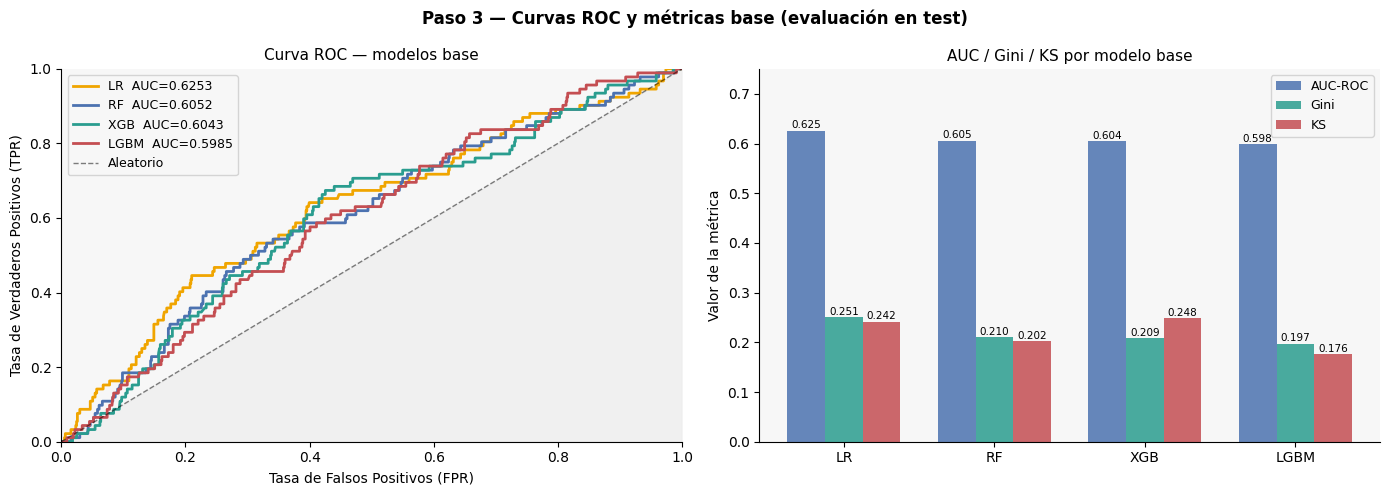

In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# Curvas ROC comparativas (modelos base)
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Paso 3 — Curvas ROC y métricas base (evaluación en test)",
             fontsize=12, fontweight="bold")
 
# Panel izquierdo: curvas ROC
ax = axes[0]
for nombre, res in resultados_base.items():
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    ax.plot(fpr, tpr, linewidth=2, color=COLORES_MOD[nombre],
            label=f"{nombre}  AUC={res['AUC']:.4f}")
 
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Aleatorio")
ax.fill_between([0, 1], [0, 1], alpha=0.05, color="gray")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax.set_title("Curva ROC — modelos base")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
 
# Panel derecho: barras comparativas AUC / KS / Gini
ax2 = axes[1]
nombres  = list(resultados_base.keys())
x        = np.arange(len(nombres))
w        = 0.25
 
aucs  = [resultados_base[n]["AUC"]  for n in nombres]
ginis = [resultados_base[n]["Gini"] for n in nombres]
ks    = [resultados_base[n]["KS"]   for n in nombres]
 
ax2.bar(x - w,   aucs,  width=w, label="AUC-ROC", color=COLOR_BUENO,  alpha=0.85)
ax2.bar(x,       ginis, width=w, label="Gini",     color=COLOR_NEU,    alpha=0.85)
ax2.bar(x + w,   ks,    width=w, label="KS",       color=COLOR_MALO,   alpha=0.85)
 
for i, n in enumerate(nombres):
    ax2.text(i - w,   aucs[i]  + 0.005, f"{aucs[i]:.3f}",  ha="center", fontsize=7.5)
    ax2.text(i,       ginis[i] + 0.005, f"{ginis[i]:.3f}", ha="center", fontsize=7.5)
    ax2.text(i + w,   ks[i]    + 0.005, f"{ks[i]:.3f}",    ha="center", fontsize=7.5)
 
ax2.set_xticks(x)
ax2.set_xticklabels(nombres)
ax2.set_ylabel("Valor de la métrica")
ax2.set_title("AUC / Gini / KS por modelo base")
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(aucs) * 1.2)
 
plt.tight_layout()
plt.show()

## Paso 4 — Búsqueda de hiperparámetros
 
### Estrategia
 
Se usa `RandomizedSearchCV` sobre `TimeSeriesSplit(n_splits=4)` para
respetar el orden cronológico de los datos en la validación cruzada.
 
**¿Por qué RandomizedSearch y no GridSearch?**
Con 3 modelos y espacios de hiperparámetros amplios, GridSearch puede
requerir cientos de combinaciones. RandomizedSearch explora `n_iter`
combinaciones aleatorias — con `n_iter=30` cubre bien el espacio
preservando tiempo de cómputo.
 
**¿Por qué TimeSeriesSplit en el CV?**
El mismo criterio del split global: los datos tienen tendencia temporal
y estacionalidad. Mezclar fechas en el CV generaría data leakage en
la validación cruzada.
 
### Sobre SMOTE en el CV
Para LR y RF se evaluará una variante con SMOTE usando `ImbPipeline`
de `imbalanced-learn`, que garantiza que el oversample se aplica
**solo dentro de cada fold de train**, nunca en el fold de validación.
 
### Métrica de optimización: AUC-ROC
Más estable que KS para optimizar en CV. El KS se reporta en la
evaluación final sobre test.

In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# Configurar CV y espacios de búsqueda
# ─────────────────────────────────────────────────────────────────────────────
 
from scipy.stats import randint, uniform
 
# TimeSeriesSplit con test_size = 20% del train
N_TEST_CV = int(len(X_train) * 0.20)   # 690
tscv      = TimeSeriesSplit(n_splits=4, test_size=N_TEST_CV)
 
print(f"CV: TimeSeriesSplit | n_splits=4 | test_size={N_TEST_CV} por fold")
print(f"Métrica de optimización: AUC-ROC\n")

# ── Espacio de hiperparámetros ─────────────────────────────────────────────
 
# Logistic Regression
# C: inverso de la regularización — valores pequeños = más regularización
# penalty: L1 (Lasso, selección de variables) vs L2 (Ridge, shrinkage)
# solver: saga soporta ambas penalidades
param_lr = {
    "modelo__C"       : uniform(loc=0.001, scale=9.999),  # 0.001 a 10
    "modelo__penalty" : ["l1", "l2"],
    "modelo__solver"  : ["saga"],
}
 
# Random Forest
# n_estimators: más árboles = más estable pero más lento
# max_depth: controla sobreajuste — None = sin límite (puede overfit)
# min_samples_leaf: mínimo de muestras en hoja — clave con pocas clases
# max_features: fracción de features por split
param_rf = {
    "n_estimators"   : randint(100, 500),
    "max_depth"      : [5, 8, 10, 15, None],
    "min_samples_leaf": randint(5, 30),
    "max_features"   : ["sqrt", "log2", 0.5, 0.7],
}
 
# XGBoost
# learning_rate + n_estimators: relación inversa — LR bajo necesita más árboles
# subsample: fracción de datos por árbol — reduce overfitting
# colsample_bytree: fracción de features por árbol
# gamma: mínima ganancia para hacer un split — regularización
param_xgb = {
    "n_estimators"    : randint(100, 600),
    "max_depth"       : randint(3, 9),
    "learning_rate"   : uniform(0.01, 0.19),
    "subsample"       : uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma"           : uniform(0, 0.5),
    "reg_alpha"       : uniform(0, 1),      # L1
    "reg_lambda"      : uniform(0.5, 4.5),  # L2
}
 
# LightGBM
# num_leaves: controla la complejidad del árbol (< 2^max_depth)
# min_child_samples: mínimo de muestras por hoja — clave con malos=412
# feature_fraction: equivalente a colsample_bytree de XGB
# bagging_fraction + bagging_freq: stochastic gradient boosting
param_lgbm = {
    "n_estimators"     : randint(100, 600),
    "max_depth"        : randint(3, 9),
    "learning_rate"    : uniform(0.01, 0.19),
    "num_leaves"       : randint(15, 63),
    "min_child_samples": randint(10, 50),
    "feature_fraction" : uniform(0.6, 0.4),
    "bagging_fraction" : uniform(0.6, 0.4),
    "bagging_freq"     : randint(1, 7),
    "reg_alpha"        : uniform(0, 1),
    "reg_lambda"       : uniform(0, 5),
}
 
print("Espacios de búsqueda definidos:")
print(f"  LR   : {len(param_lr)} hiperparámetros")
print(f"  RF   : {len(param_rf)} hiperparámetros")
print(f"  XGB  : {len(param_xgb)} hiperparámetros")
print(f"  LGBM : {len(param_lgbm)} hiperparámetros")

CV: TimeSeriesSplit | n_splits=4 | test_size=690 por fold
Métrica de optimización: AUC-ROC

Espacios de búsqueda definidos:
  LR   : 3 hiperparámetros
  RF   : 4 hiperparámetros
  XGB  : 8 hiperparámetros
  LGBM : 10 hiperparámetros


In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# Búsqueda para LR (con y sin SMOTE)
# ─────────────────────────────────────────────────────────────────────────────
 
print("Buscando hiperparámetros — LR...")
print("─" * 50)
 
# Variante 1: class_weight='balanced' (sin SMOTE)
search_lr = RandomizedSearchCV(
    estimator  = Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=42
        ))
    ]),
    param_distributions = param_lr,
    n_iter       = 30,
    cv           = tscv,
    scoring      = "roc_auc",
    refit        = True,
    n_jobs       = -1,
    random_state = 42,
    verbose      = 0,
)
search_lr.fit(X_train, y_train)
 
# Variante 2: SMOTE dentro del pipeline
search_lr_smote = RandomizedSearchCV(
    estimator = ImbPipeline([
        ("smote",  SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    param_distributions = param_lr,
    n_iter       = 30,
    cv           = tscv,
    scoring      = "roc_auc",
    refit        = True,
    n_jobs       = -1,
    random_state = 42,
    verbose      = 0,
)
search_lr_smote.fit(X_train, y_train)
 
# Comparar variantes en test
auc_lr       = roc_auc_score(y_test, search_lr.best_estimator_.predict_proba(X_test)[:, 1])
auc_lr_smote = roc_auc_score(y_test, search_lr_smote.best_estimator_.predict_proba(X_test)[:, 1])
 
print(f"  LR  (balanced)  — CV AUC={search_lr.best_score_:.4f}       | Test AUC={auc_lr:.4f}")
print(f"  LR  (SMOTE)     — CV AUC={search_lr_smote.best_score_:.4f} | Test AUC={auc_lr_smote:.4f}")
 
# Seleccionar mejor variante de LR
if auc_lr >= auc_lr_smote:
    mejor_lr      = search_lr.best_estimator_
    mejor_lr_tag  = "LR (balanced)"
    mejor_lr_auc  = auc_lr
    print(f"\n  ✅ Mejor LR: balanced (AUC={auc_lr:.4f})")
else:
    mejor_lr      = search_lr_smote.best_estimator_
    mejor_lr_tag  = "LR (SMOTE)"
    mejor_lr_auc  = auc_lr_smote
    print(f"\n  ✅ Mejor LR: SMOTE (AUC={auc_lr_smote:.4f})")
 
print(f"\n  Mejores hiperparámetros LR:")
for k, v in search_lr.best_params_.items():
    print(f"    {k}: {v}")

Buscando hiperparámetros — LR...
──────────────────────────────────────────────────
  LR  (balanced)  — CV AUC=0.6228       | Test AUC=0.6253
  LR  (SMOTE)     — CV AUC=0.6215 | Test AUC=0.6346

  ✅ Mejor LR: SMOTE (AUC=0.6346)

  Mejores hiperparámetros LR:
    modelo__C: 0.34485082263106875
    modelo__penalty: l2
    modelo__solver: saga


In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# Búsqueda para RF (con y sin SMOTE)
# ─────────────────────────────────────────────────────────────────────────────
 
print("Buscando hiperparámetros — RF...")
print("─" * 50)
 
# Variante 1: class_weight='balanced'
search_rf = RandomizedSearchCV(
    estimator = RandomForestClassifier(
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    param_distributions = param_rf,
    n_iter       = 30,
    cv           = tscv,
    scoring      = "roc_auc",
    refit        = True,
    n_jobs       = -1,
    random_state = 42,
    verbose      = 0,
)
search_rf.fit(X_train, y_train)
 
# Variante 2: SMOTE
search_rf_smote = RandomizedSearchCV(
    estimator = ImbPipeline([
        ("smote",  SMOTE(random_state=42)),
        ("modelo", RandomForestClassifier(random_state=42, n_jobs=-1)),
    ]),
    param_distributions = {f"modelo__{k}": v for k, v in param_rf.items()},
    n_iter       = 30,
    cv           = tscv,
    scoring      = "roc_auc",
    refit        = True,
    n_jobs       = -1,
    random_state = 42,
    verbose      = 0,
)
search_rf_smote.fit(X_train, y_train)
 
auc_rf       = roc_auc_score(y_test, search_rf.best_estimator_.predict_proba(X_test)[:, 1])
auc_rf_smote = roc_auc_score(y_test, search_rf_smote.best_estimator_.predict_proba(X_test)[:, 1])
 
print(f"  RF  (balanced)  — CV AUC={search_rf.best_score_:.4f}       | Test AUC={auc_rf:.4f}")
print(f"  RF  (SMOTE)     — CV AUC={search_rf_smote.best_score_:.4f} | Test AUC={auc_rf_smote:.4f}")
 
if auc_rf >= auc_rf_smote:
    mejor_rf     = search_rf.best_estimator_
    mejor_rf_tag = "RF (balanced)"
    mejor_rf_auc = auc_rf
    print(f"\n  ✅ Mejor RF: balanced (AUC={auc_rf:.4f})")
else:
    mejor_rf     = search_rf_smote.best_estimator_
    mejor_rf_tag = "RF (SMOTE)"
    mejor_rf_auc = auc_rf_smote
    print(f"\n  ✅ Mejor RF: SMOTE (AUC={auc_rf_smote:.4f})")
 
print(f"\n  Mejores hiperparámetros RF:")
for k, v in search_rf.best_params_.items():
    print(f"    {k}: {v}")

Buscando hiperparámetros — RF...
──────────────────────────────────────────────────
  RF  (balanced)  — CV AUC=0.6131       | Test AUC=0.6381
  RF  (SMOTE)     — CV AUC=0.5913 | Test AUC=0.6151

  ✅ Mejor RF: balanced (AUC=0.6381)

  Mejores hiperparámetros RF:
    max_depth: 8
    max_features: sqrt
    min_samples_leaf: 25
    n_estimators: 485


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# Búsqueda para XGBoost
# ─────────────────────────────────────────────────────────────────────────────
 
print("Buscando hiperparámetros — XGBoost...")
print("─" * 50)
 
search_xgb = RandomizedSearchCV(
    estimator = xgb.XGBClassifier(
        scale_pos_weight  = RATIO_DESBALANCE,
        eval_metric       = "auc",
        use_label_encoder = False,
        random_state      = 42,
        n_jobs            = -1,
    ),
    param_distributions = param_xgb,
    n_iter       = 30,
    cv           = tscv,
    scoring      = "roc_auc",
    refit        = True,
    n_jobs       = -1,
    random_state = 42,
    verbose      = 0,
)
search_xgb.fit(X_train, y_train)
 
mejor_xgb     = search_xgb.best_estimator_
mejor_xgb_auc = roc_auc_score(y_test, mejor_xgb.predict_proba(X_test)[:, 1])
 
print(f"  XGB             — CV AUC={search_xgb.best_score_:.4f}       | Test AUC={mejor_xgb_auc:.4f}")
print(f"\n  Mejores hiperparámetros XGB:")
for k, v in search_xgb.best_params_.items():
    print(f"    {k}: {v}")

Buscando hiperparámetros — XGBoost...
──────────────────────────────────────────────────
  XGB             — CV AUC=0.6022       | Test AUC=0.6114

  Mejores hiperparámetros XGB:
    colsample_bytree: 0.8497416192535173
    gamma: 0.147816842918857
    learning_rate: 0.030043909367751413
    max_depth: 6
    n_estimators: 127
    reg_alpha: 0.2184404372168336
    reg_lambda: 2.374294765416648
    subsample: 0.9533121035675474


In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# Búsqueda para LightGBM
# ─────────────────────────────────────────────────────────────────────────────
 
print("Buscando hiperparámetros — LightGBM...")
print("─" * 50)
 
search_lgbm = RandomizedSearchCV(
    estimator = lgb.LGBMClassifier(
        is_unbalance = True,
        random_state = 42,
        n_jobs       = -1,
        verbose      = -1,
    ),
    param_distributions = param_lgbm,
    n_iter       = 30,
    cv           = tscv,
    scoring      = "roc_auc",
    refit        = True,
    n_jobs       = -1,
    random_state = 42,
    verbose      = 0,
)
search_lgbm.fit(X_train, y_train)
 
mejor_lgbm     = search_lgbm.best_estimator_
mejor_lgbm_auc = roc_auc_score(y_test, mejor_lgbm.predict_proba(X_test)[:, 1])
 
print(f"  LGBM            — CV AUC={search_lgbm.best_score_:.4f}       | Test AUC={mejor_lgbm_auc:.4f}")
print(f"\n  Mejores hiperparámetros LGBM:")
for k, v in search_lgbm.best_params_.items():
    print(f"    {k}: {v}")

Buscando hiperparámetros — LightGBM...
──────────────────────────────────────────────────
  LGBM            — CV AUC=0.5927       | Test AUC=0.6101

  Mejores hiperparámetros LGBM:
    bagging_fraction: 0.7292811728083021
    bagging_freq: 1
    feature_fraction: 0.7615344684232164
    learning_rate: 0.022329526950706495
    max_depth: 4
    min_child_samples: 21
    n_estimators: 394
    num_leaves: 16
    reg_alpha: 0.712270589924442
    reg_lambda: 0.7404346497669995


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# Tabla comparativa final y curvas ROC post-tuning
# ─────────────────────────────────────────────────────────────────────────────
 
# Consolidar resultados post-tuning
modelos_tuned = {
    "LR"  : mejor_lr,
    "RF"  : mejor_rf,
    "XGB" : mejor_xgb,
    "LGBM": mejor_lgbm,
}
 
resultados_tuned = {}
print("═" * 60)
print("RESULTADOS POST-TUNING — evaluación en test")
print("═" * 60)
print(f"  {'Modelo':<22} {'CV AUC':>8} {'Test AUC':>9} {'Gini':>7} {'KS':>7}")
print("  " + "─" * 56)
 
cv_aucs = {
    "LR"  : search_lr.best_score_,
    "RF"  : search_rf.best_score_,
    "XGB" : search_xgb.best_score_,
    "LGBM": search_lgbm.best_score_,
}
 
for nombre, modelo in modelos_tuned.items():
    proba       = modelo.predict_proba(X_test)[:, 1]
    auc         = roc_auc_score(y_test, proba)
    gini        = 2 * auc - 1
    fpr, tpr, _ = roc_curve(y_test, proba)
    ks          = (tpr - fpr).max()
    resultados_tuned[nombre] = {
        "AUC": auc, "Gini": gini, "KS": ks,
        "CV_AUC": cv_aucs[nombre],
        "proba": proba, "modelo": modelo,
    }
    ovf = auc - cv_aucs[nombre]
    flag = "⚠️ " if ovf > 0.05 else "✅"
    print(f"  {flag} {nombre:<20} {cv_aucs[nombre]:>8.4f} {auc:>9.4f} "
          f"{gini:>7.4f} {ks:>7.4f}")
 
print("═" * 60)
mejor_final = max(resultados_tuned, key=lambda k: resultados_tuned[k]["AUC"])
print(f"\n  🏆 Mejor modelo post-tuning: {mejor_final} "
      f"— AUC={resultados_tuned[mejor_final]['AUC']:.4f} "
      f"| KS={resultados_tuned[mejor_final]['KS']:.4f}")

════════════════════════════════════════════════════════════
RESULTADOS POST-TUNING — evaluación en test
════════════════════════════════════════════════════════════
  Modelo                   CV AUC  Test AUC    Gini      KS
  ────────────────────────────────────────────────────────
  ✅ LR                     0.6228    0.6346  0.2692  0.2431
  ✅ RF                     0.6131    0.6381  0.2762  0.2767
  ✅ XGB                    0.6022    0.6114  0.2228  0.2250
  ✅ LGBM                   0.5927    0.6101  0.2201  0.2017
════════════════════════════════════════════════════════════

  🏆 Mejor modelo post-tuning: RF — AUC=0.6381 | KS=0.2767


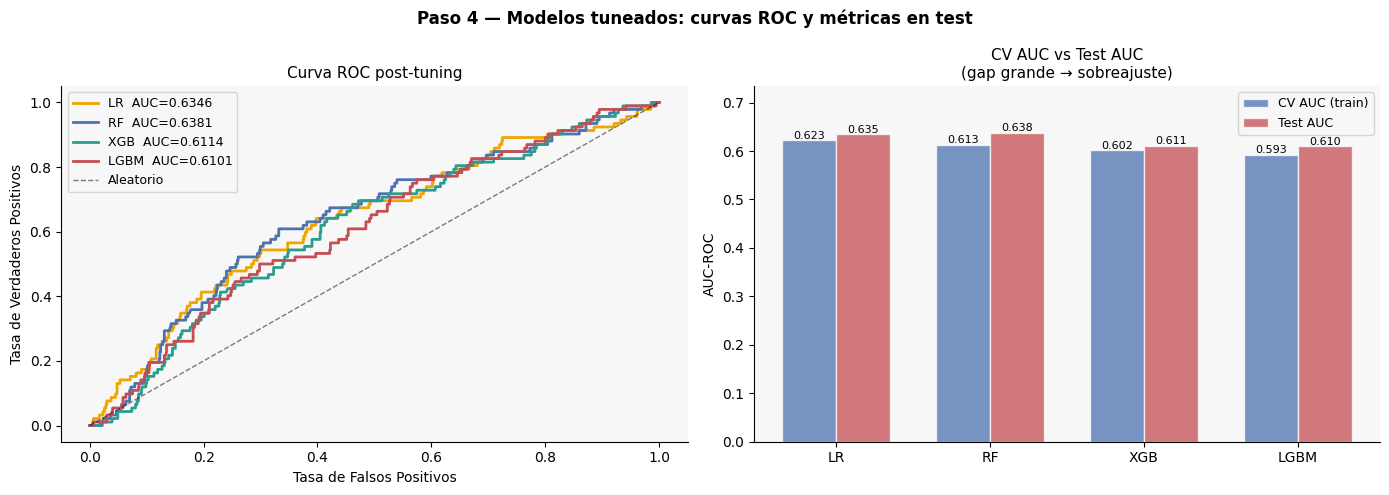

In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualización comparativa post-tuning
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Paso 4 — Modelos tuneados: curvas ROC y métricas en test",
             fontsize=12, fontweight="bold")
 
# Curvas ROC
ax = axes[0]
for nombre, res in resultados_tuned.items():
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    ax.plot(fpr, tpr, linewidth=2, color=COLORES_MOD[nombre],
            label=f"{nombre}  AUC={res['AUC']:.4f}")
 
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curva ROC post-tuning")
ax.legend(fontsize=9)
 
# CV AUC vs Test AUC — detección de overfitting
ax2   = axes[1]
names = list(resultados_tuned.keys())
x     = np.arange(len(names))
w     = 0.35
 
cv_v  = [resultados_tuned[n]["CV_AUC"] for n in names]
te_v  = [resultados_tuned[n]["AUC"]    for n in names]
 
ax2.bar(x - w/2, cv_v, width=w, label="CV AUC (train)",
        color=COLOR_BUENO, alpha=0.75, edgecolor="white")
ax2.bar(x + w/2, te_v, width=w, label="Test AUC",
        color=COLOR_MALO,  alpha=0.75, edgecolor="white")
 
for i, (cv, te) in enumerate(zip(cv_v, te_v)):
    ax2.text(i - w/2, cv + 0.003, f"{cv:.3f}", ha="center", fontsize=8)
    ax2.text(i + w/2, te + 0.003, f"{te:.3f}", ha="center", fontsize=8)
 
ax2.set_xticks(x)
ax2.set_xticklabels(names)
ax2.set_ylabel("AUC-ROC")
ax2.set_title("CV AUC vs Test AUC\n(gap grande → sobreajuste)")
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(cv_v + te_v) * 1.15)
 
plt.tight_layout()
plt.show()

AUC=0.63 no es catastrófico para este problema específico. En crédito de alto riesgo con datos limitados, AUC entre 0.60-0.70 es común y operacionalmente útil. Un modelo con AUC=0.63 sigue siendo mucho mejor que decisiones aleatorias o basadas solo en reglas manuales.

## Paso 5 — Evaluación comparativa de modelos
 
Con los cuatro modelos tuneados se realiza una evaluación exhaustiva sobre
el conjunto de **test** (período más reciente, nunca visto en entrenamiento).
 
### Métricas evaluadas
 
| Métrica | Fórmula | Relevancia en crédito |
|---|---|---|
| **AUC-ROC** | Área bajo curva ROC | Discriminación global — independiente del corte |
| **Gini** | 2 × AUC − 1 | Estándar regulatorio en banca |
| **KS** | max(TPR − FPR) | Métrica operativa principal en Colombia |
| **Precision** | VP / (VP + FP) | De los que el modelo marca como malos, ¿cuántos lo son? |
| **Recall** | VP / (VP + FN) | De los malos reales, ¿cuántos detecta el modelo? |
| **F1** | 2 × (P × R) / (P + R) | Balance Precision-Recall |
 
### Criterio de selección del modelo final
El modelo ganador será el que presente el **mejor KS** en test,
desempatando por AUC-ROC. El KS es la métrica que el equipo de Riesgo
usa directamente para definir el punto de corte operativo.

In [83]:
# ─────────────────────────────────────────────────────────────────────────────
# Función central de evaluación
# ─────────────────────────────────────────────────────────────────────────────
 
def evaluar_modelo(nombre, modelo, X, y, umbral=0.5):
    """
    Calcula el conjunto completo de métricas para un modelo.
 
    Parámetros
    ----------
    nombre  : etiqueta del modelo
    modelo  : objeto entrenado con predict_proba
    X       : features de evaluación
    y       : target real
    umbral  : punto de corte para métricas de clasificación (default 0.5)
 
    Retorna
    -------
    dict con todas las métricas y probabilidades predichas
    """
    proba        = modelo.predict_proba(X)[:, 1]
    pred         = (proba >= umbral).astype(int)
 
    auc          = roc_auc_score(y, proba)
    gini         = 2 * auc - 1
    fpr, tpr, _  = roc_curve(y, proba)
    ks           = float((tpr - fpr).max())
    precision    = precision_score(y, pred, zero_division=0)
    recall       = recall_score(y, pred, zero_division=0)
    f1           = f1_score(y, pred, zero_division=0)
    cm           = confusion_matrix(y, pred)
 
    return {
        "nombre"   : nombre,
        "AUC"      : auc,
        "Gini"     : gini,
        "KS"       : ks,
        "Precision": precision,
        "Recall"   : recall,
        "F1"       : f1,
        "CM"       : cm,
        "proba"    : proba,
        "fpr"      : fpr,
        "tpr"      : tpr,
    }
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Evaluar todos los modelos y tabla comparativa
# ─────────────────────────────────────────────────────────────────────────────
 
# Evaluar los 4 modelos sobre test
# 'modelos_tuned' viene del Paso 4: {"LR": modelo, "RF": modelo, ...}
resultados = {
    nombre: evaluar_modelo(nombre, modelo, X_test, y_test)
    for nombre, modelo in modelos_tuned.items()
}
 
# ── Tabla comparativa ─────────────────────────────────────────────────────
df_resultados = pd.DataFrame([
    {
        "Modelo"    : r["nombre"],
        "AUC-ROC"   : round(r["AUC"],       4),
        "Gini"      : round(r["Gini"],      4),
        "KS"        : round(r["KS"],        4),
        "Precision" : round(r["Precision"], 4),
        "Recall"    : round(r["Recall"],    4),
        "F1"        : round(r["F1"],        4),
    }
    for r in resultados.values()
]).sort_values("KS", ascending=False).reset_index(drop=True)
 
print("═" * 72)
print("EVALUACIÓN COMPARATIVA — test set")
print("═" * 72)
print(df_resultados.to_string(index=False))
print("═" * 72)
 
# Destacar ganador
ganador = df_resultados.iloc[0]["Modelo"]
print(f"\n  🏆 Mejor modelo por KS: {ganador}")
print(f"     KS={df_resultados.iloc[0]['KS']:.4f} | "
      f"AUC={df_resultados.iloc[0]['AUC-ROC']:.4f} | "
      f"Gini={df_resultados.iloc[0]['Gini']:.4f}")

════════════════════════════════════════════════════════════════════════
EVALUACIÓN COMPARATIVA — test set
════════════════════════════════════════════════════════════════════════
Modelo  AUC-ROC   Gini     KS  Precision  Recall     F1
    RF   0.6381 0.2762 0.2767     0.1912  0.5217 0.2799
    LR   0.6346 0.2692 0.2431     0.1595  0.6413 0.2554
   XGB   0.6114 0.2228 0.2250     0.1591  0.4565 0.2360
  LGBM   0.6101 0.2201 0.2017     0.1631  0.5000 0.2460
════════════════════════════════════════════════════════════════════════

  🏆 Mejor modelo por KS: RF
     KS=0.2767 | AUC=0.6381 | Gini=0.2762


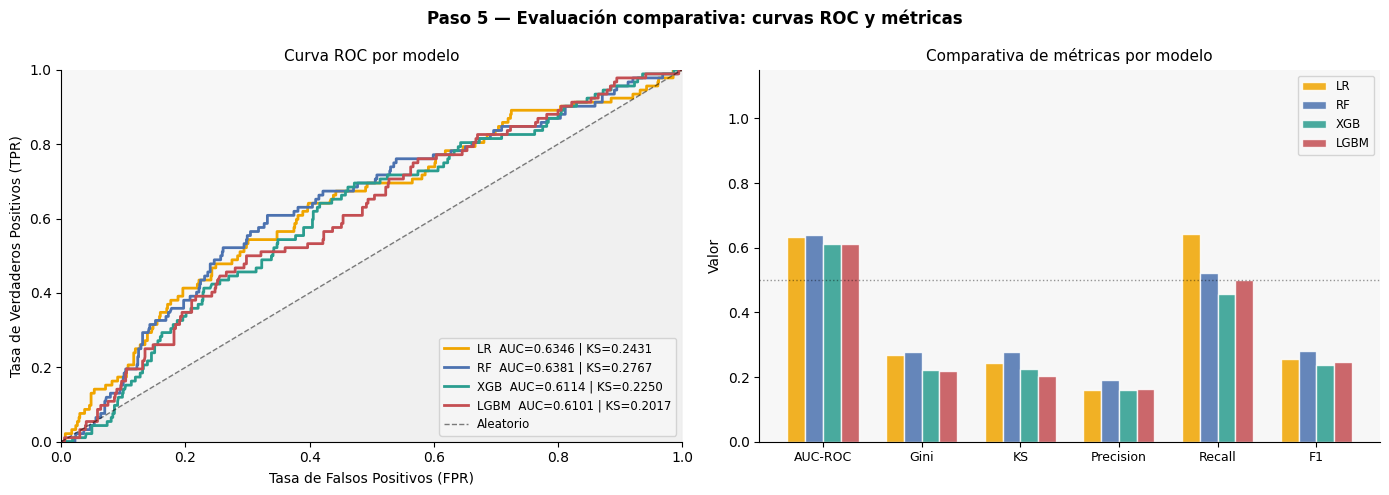

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Curvas ROC comparativas
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Paso 5 — Evaluación comparativa: curvas ROC y métricas",
             fontsize=12, fontweight="bold")
 
# Panel izquierdo: curvas ROC
ax = axes[0]
for nombre, res in resultados.items():
    ax.plot(res["fpr"], res["tpr"], linewidth=2,
            color=COLORES_MOD[nombre],
            label=f"{nombre}  AUC={res['AUC']:.4f} | KS={res['KS']:.4f}")
 
ax.fill_between([0, 1], [0, 1], alpha=0.05, color="gray")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax.set_title("Curva ROC por modelo")
ax.legend(fontsize=8.5, loc="lower right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
 
# Panel derecho: spider/barras de métricas
ax2      = axes[1]
metricas = ["AUC-ROC", "Gini", "KS", "Precision", "Recall", "F1"]
nombres  = list(resultados.keys())
x        = np.arange(len(metricas))
w        = 0.18
 
for i, nombre in enumerate(nombres):
    vals = [df_resultados[df_resultados["Modelo"] == nombre][m].values[0]
            for m in metricas]
    bars = ax2.bar(x + i * w, vals, width=w,
                   color=COLORES_MOD[nombre], alpha=0.85,
                   label=nombre, edgecolor="white")
 
ax2.set_xticks(x + w * (len(nombres) - 1) / 2)
ax2.set_xticklabels(metricas, fontsize=9)
ax2.set_ylabel("Valor")
ax2.set_title("Comparativa de métricas por modelo")
ax2.legend(fontsize=8.5)
ax2.set_ylim(0, 1.15)
ax2.axhline(0.5, color="black", linestyle=":", linewidth=1,
            alpha=0.4, label="Referencia 0.5")
 
plt.tight_layout()
plt.show()

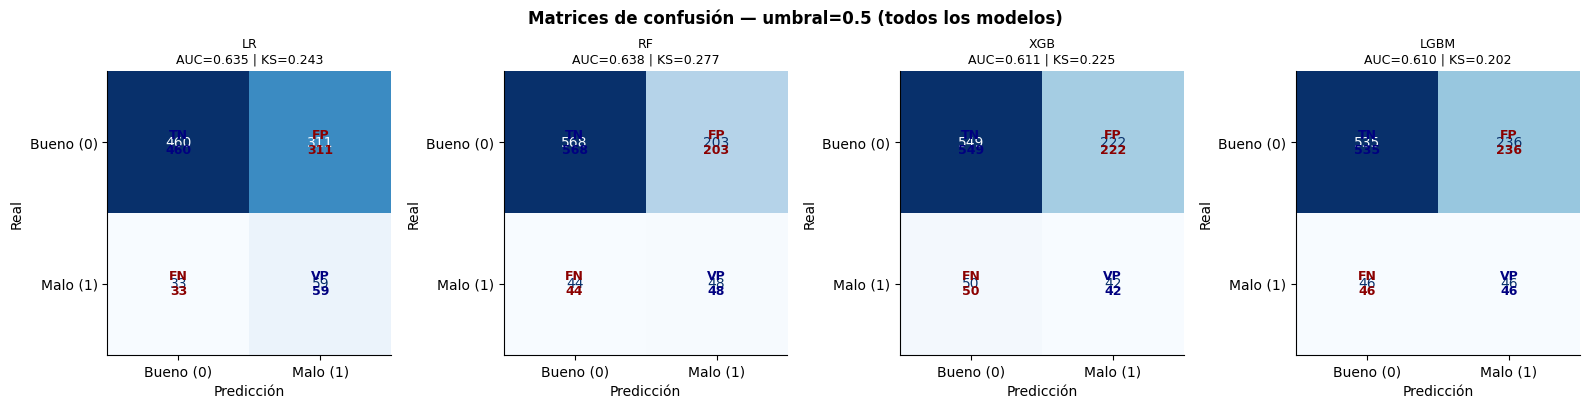


Matriz de confusión — RF (umbral=0.5):
  Verdaderos Negativos (TN) :  568  — buenos correctamente aprobados
  Falsos Positivos     (FP) :  203  — buenos rechazados (costo de oportunidad)
  Falsos Negativos     (FN) :   44  — malos aprobados   ← riesgo crediticio
  Verdaderos Positivos (VP) :   48  — malos correctamente rechazados

  De 92 malos reales, el modelo detecta 48 (52.2%)
  De 771 buenos reales, aprueba 568 (73.7%)


In [85]:
# ─────────────────────────────────────────────────────────────────────────────
# Matrices de confusión (4 modelos)
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Matrices de confusión — umbral=0.5 (todos los modelos)",
             fontsize=12, fontweight="bold")
 
for ax, (nombre, res) in zip(axes, resultados.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=res["CM"],
        display_labels=["Bueno (0)", "Malo (1)"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{nombre}\nAUC={res['AUC']:.3f} | KS={res['KS']:.3f}",
                 fontsize=9)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
 
    # Anotar TN, FP, FN, VP con etiquetas claras
    tn, fp, fn, vp = res["CM"].ravel()
    ax.text(0, 0, f"TN\n{tn}", ha="center", va="center",
            fontsize=9, fontweight="bold", color="navy")
    ax.text(1, 0, f"FP\n{fp}", ha="center", va="center",
            fontsize=9, fontweight="bold", color="darkred")
    ax.text(0, 1, f"FN\n{fn}", ha="center", va="center",
            fontsize=9, fontweight="bold", color="darkred")
    ax.text(1, 1, f"VP\n{vp}", ha="center", va="center",
            fontsize=9, fontweight="bold", color="navy")
 
plt.tight_layout()
plt.show()
 
# Interpretación rápida de la matriz del mejor modelo
res_gan  = resultados[ganador]
tn, fp, fn, vp = res_gan["CM"].ravel()
print(f"\nMatriz de confusión — {ganador} (umbral=0.5):")
print(f"  Verdaderos Negativos (TN) : {tn:>4}  — buenos correctamente aprobados")
print(f"  Falsos Positivos     (FP) : {fp:>4}  — buenos rechazados (costo de oportunidad)")
print(f"  Falsos Negativos     (FN) : {fn:>4}  — malos aprobados   ← riesgo crediticio")
print(f"  Verdaderos Positivos (VP) : {vp:>4}  — malos correctamente rechazados")
print(f"\n  De {y_test.sum()} malos reales, el modelo detecta {vp} ({vp/y_test.sum():.1%})")
print(f"  De {(y_test==0).sum()} buenos reales, aprueba {tn} ({tn/(y_test==0).sum():.1%})")

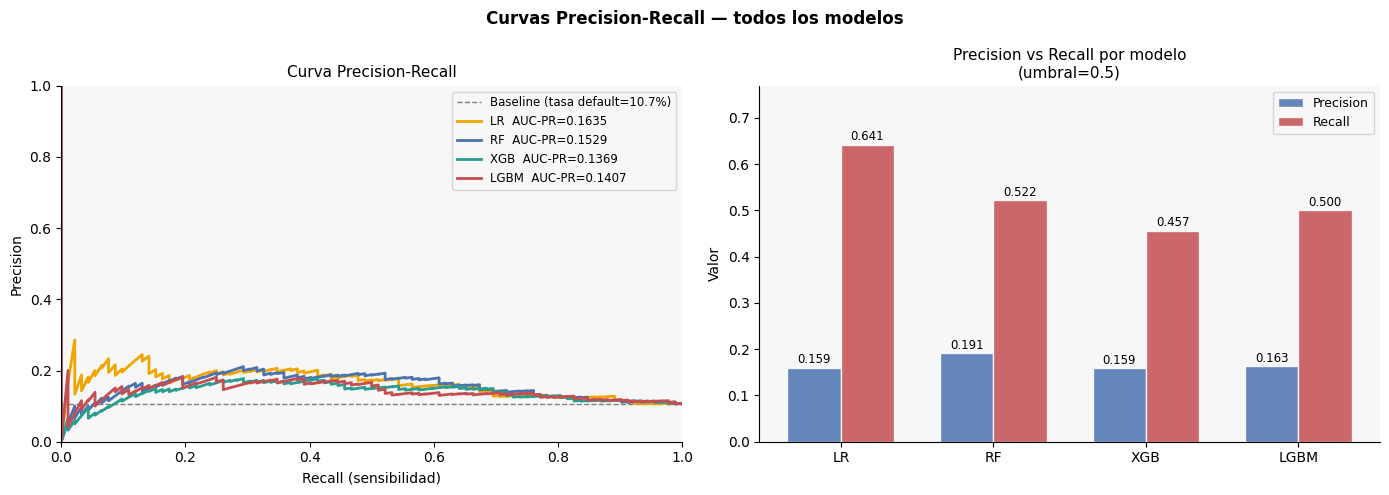

In [86]:
# ─────────────────────────────────────────────────────────────────────────────
# Curvas Precision-Recall
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curvas Precision-Recall — todos los modelos",
             fontsize=12, fontweight="bold")
 
# Panel izquierdo: PR curves
ax = axes[0]
# Baseline: tasa de default en test (modelo sin discriminación)
baseline_pr = y_test.mean()
ax.axhline(baseline_pr, color="gray", linestyle="--", linewidth=1,
           label=f"Baseline (tasa default={baseline_pr:.1%})")
 
for nombre, res in resultados.items():
    prec, rec, _ = precision_recall_curve(y_test, res["proba"])
    # AUC-PR
    auc_pr = np.trapz(prec[::-1], rec[::-1])
    ax.plot(rec, prec, linewidth=2, color=COLORES_MOD[nombre],
            label=f"{nombre}  AUC-PR={auc_pr:.4f}")
 
ax.set_xlabel("Recall (sensibilidad)")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall")
ax.legend(fontsize=8.5, loc="upper right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
 
# Panel derecho: Precision y Recall por modelo a umbral=0.5
ax2      = axes[1]
nombres  = list(resultados.keys())
precs    = [resultados[n]["Precision"] for n in nombres]
recs     = [resultados[n]["Recall"]    for n in nombres]
x        = np.arange(len(nombres))
w        = 0.35
 
bars_p = ax2.bar(x - w/2, precs, width=w, label="Precision",
                  color=COLOR_BUENO, alpha=0.85, edgecolor="white")
bars_r = ax2.bar(x + w/2, recs,  width=w, label="Recall",
                  color=COLOR_MALO, alpha=0.85, edgecolor="white")
 
for bar, v in zip(bars_p, precs):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f"{v:.3f}", ha="center", fontsize=8.5)
for bar, v in zip(bars_r, recs):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f"{v:.3f}", ha="center", fontsize=8.5)
 
ax2.set_xticks(x)
ax2.set_xticklabels(nombres)
ax2.set_ylabel("Valor")
ax2.set_title("Precision vs Recall por modelo\n(umbral=0.5)")
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(precs + recs) * 1.2)
 
plt.tight_layout()
plt.show()

### Coeficientes de Logistic Regression
 
Los coeficientes de LR son directamente interpretables como la
**contribución de cada variable a la probabilidad de incumplimiento**,
siempre que las variables estén en la misma escala.
 
Como se aplicó `StandardScaler` en el pipeline de LR, los coeficientes
están **estandarizados** — son comparables entre sí sin importar la
escala original de cada variable.
 
**Lectura del coeficiente:**
- **Positivo** → a mayor valor de la variable, mayor probabilidad de Mora60=1
- **Negativo** → a mayor valor de la variable, menor probabilidad de Mora60=1
- **Magnitud** → cuánto "pesa" esa variable en la decisión final
 
**Nota sobre variables WoE:**
`woe_nivel_academico_agrup` y `woe_estado_civil_agrup` están en escala
de Weight of Evidence — un coeficiente negativo significa que a mayor
WoE (más perfil de buen pagador), menor probabilidad de incumplimiento.
Eso es consistente con la definición del WoE.

In [87]:
# ─────────────────────────────────────────────────────────────────────────────
# Extraer e interpretar coeficientes de LR
# ─────────────────────────────────────────────────────────────────────────────
 
# Extraer el step de LR desde el pipeline
# mejor_lr viene del Paso 4 (mejor variante: balanced o SMOTE)
lr_model = mejor_lr.named_steps["modelo"]
coefs    = lr_model.coef_[0]
 
# Construir DataFrame de coeficientes
df_coef = (pd.DataFrame({
                "feature"    : FEATURES,
                "coeficiente": coefs,
            })
            .assign(
                abs_coef   = lambda x: x["coeficiente"].abs(),
                direccion  = lambda x: x["coeficiente"].apply(
                    lambda c: "↑ Aumenta riesgo" if c > 0 else "↓ Reduce riesgo"
                )
            )
            .sort_values("abs_coef", ascending=False)
            .reset_index(drop=True))
 
# Imprimir tabla
print("═" * 70)
print("COEFICIENTES LOGISTIC REGRESSION (estandarizados)")
print("═" * 70)
print(f"  {'Feature':<32} {'Coeficiente':>12}  Interpretación")
print("  " + "─" * 62)
for _, row in df_coef.iterrows():
    signo = "+" if row["coeficiente"] > 0 else ""
    print(f"  {row['feature']:<32} {signo}{row['coeficiente']:>11.4f}  "
          f"{row['direccion']}")
print("═" * 70)
print(f"\n  Intercepto: {lr_model.intercept_[0]:.4f}")
print(f"  → Probabilidad base (sin features): "
      f"{1 / (1 + np.exp(-lr_model.intercept_[0])):.2%}")

══════════════════════════════════════════════════════════════════════
COEFICIENTES LOGISTIC REGRESSION (estandarizados)
══════════════════════════════════════════════════════════════════════
  Feature                           Coeficiente  Interpretación
  ──────────────────────────────────────────────────────────────
  woe_nivel_academico_agrup            -0.2270  ↓ Reduce riesgo
  woe_estado_civil_agrup               -0.1998  ↓ Reduce riesgo
  TiempoActividadAnios                 -0.1754  ↓ Reduce riesgo
  log_tiempo_sistema                   -0.1561  ↓ Reduce riesgo
  log_tiempo_cliente                   -0.1109  ↓ Reduce riesgo
  Edad                                 -0.0816  ↓ Reduce riesgo
  PORCEND                              -0.0672  ↓ Reduce riesgo
  capacidad_pago                       -0.0199  ↓ Reduce riesgo
══════════════════════════════════════════════════════════════════════

  Intercepto: -0.0003
  → Probabilidad base (sin features): 49.99%


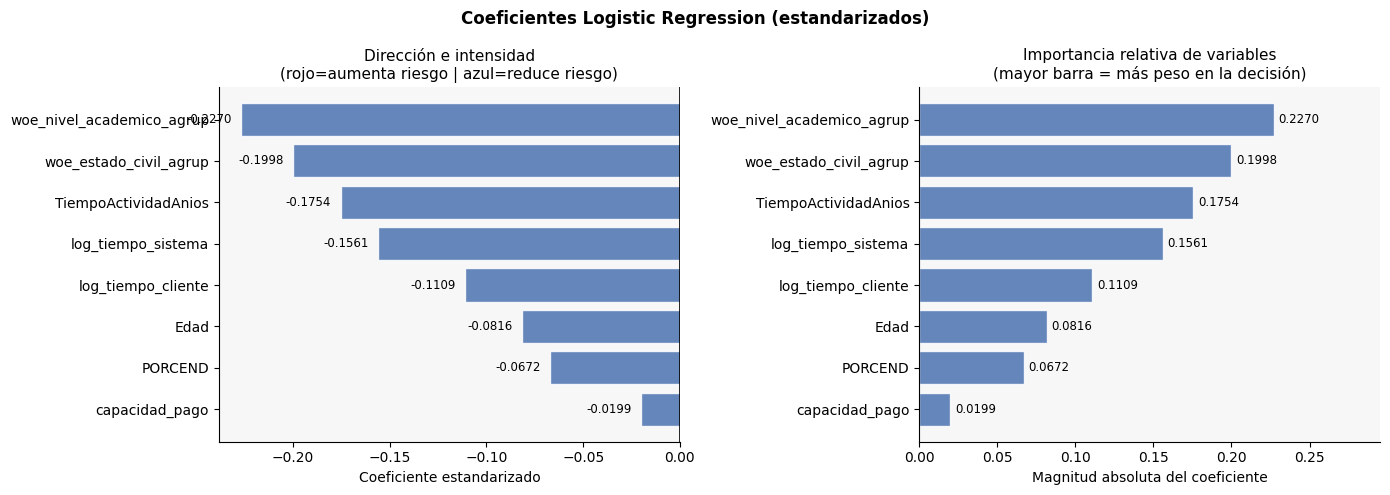

In [88]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualización coeficientes LR
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Coeficientes Logistic Regression (estandarizados)",
             fontsize=12, fontweight="bold")
 
# Panel izquierdo: barras por coeficiente
ax = axes[0]
colores_coef = [COLOR_MALO if c > 0 else COLOR_BUENO
                for c in df_coef["coeficiente"]]
bars = ax.barh(df_coef["feature"], df_coef["coeficiente"],
               color=colores_coef, edgecolor="white",
               linewidth=1, alpha=0.85)
 
ax.axvline(0, color="black", linewidth=1.2)
 
for bar, (_, row) in zip(bars, df_coef.iterrows()):
    offset = 0.005 if row["coeficiente"] >= 0 else -0.005
    ha     = "left" if row["coeficiente"] >= 0 else "right"
    ax.text(row["coeficiente"] + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{row['coeficiente']:+.4f}",
            va="center", ha=ha, fontsize=8.5)
 
ax.set_xlabel("Coeficiente estandarizado")
ax.set_title("Dirección e intensidad\n(rojo=aumenta riesgo | azul=reduce riesgo)")
ax.invert_yaxis()
 
# Panel derecho: magnitud absoluta (importancia relativa)
ax2 = axes[1]
colores_abs = [COLOR_MALO if c > 0 else COLOR_BUENO
               for c in df_coef.sort_values("abs_coef")["coeficiente"]]
df_sorted_coef = df_coef.sort_values("abs_coef")
 
bars2 = ax2.barh(df_sorted_coef["feature"],
                 df_sorted_coef["abs_coef"],
                 color=colores_abs, edgecolor="white",
                 linewidth=1, alpha=0.85)
 
for bar, (_, row) in zip(bars2, df_sorted_coef.iterrows()):
    ax2.text(row["abs_coef"] + 0.003,
             bar.get_y() + bar.get_height() / 2,
             f"{row['abs_coef']:.4f}",
             va="center", fontsize=8.5)
 
ax2.set_xlabel("Magnitud absoluta del coeficiente")
ax2.set_title("Importancia relativa de variables\n(mayor barra = más peso en la decisión)")
ax2.set_xlim(0, df_coef["abs_coef"].max() * 1.3)
 
plt.tight_layout()
plt.show()

In [89]:
# ─────────────────────────────────────────────────────────────────────────────
# Odds ratios (para presentar a negocio)
# ─────────────────────────────────────────────────────────────────────────────
# El odds ratio = exp(coeficiente) — más intuitivo para negocio:
# OR=1.5 significa "la probabilidad de incumplimiento aumenta 50%
# por cada desviación estándar de incremento en esa variable"
 
df_coef["odds_ratio"] = np.exp(df_coef["coeficiente"])
 
print("ODDS RATIOS — interpretación para negocio")
print("═" * 65)
print(f"  {'Feature':<32} {'OR':>8}  Interpretación ejecutiva")
print("  " + "─" * 60)
for _, row in df_coef.iterrows():
    or_val = row["odds_ratio"]
    if or_val > 1:
        interp = f"Cada σ adicional multiplica el riesgo por {or_val:.2f}x"
    else:
        interp = f"Cada σ adicional reduce el riesgo a {or_val:.2f}x"
    print(f"  {row['feature']:<32} {or_val:>8.4f}  {interp}")
print("═" * 65)
print("\n  OR > 1 → variable de riesgo  |  OR < 1 → variable protectora")

ODDS RATIOS — interpretación para negocio
═════════════════════════════════════════════════════════════════
  Feature                                OR  Interpretación ejecutiva
  ────────────────────────────────────────────────────────────
  woe_nivel_academico_agrup          0.7969  Cada σ adicional reduce el riesgo a 0.80x
  woe_estado_civil_agrup             0.8189  Cada σ adicional reduce el riesgo a 0.82x
  TiempoActividadAnios               0.8391  Cada σ adicional reduce el riesgo a 0.84x
  log_tiempo_sistema                 0.8555  Cada σ adicional reduce el riesgo a 0.86x
  log_tiempo_cliente                 0.8950  Cada σ adicional reduce el riesgo a 0.89x
  Edad                               0.9216  Cada σ adicional reduce el riesgo a 0.92x
  PORCEND                            0.9350  Cada σ adicional reduce el riesgo a 0.94x
  capacidad_pago                     0.9803  Cada σ adicional reduce el riesgo a 0.98x
═══════════════════════════════════════════════════════════════

El coeficiente negativo en ```woe_estado_civil_agrup``` dice: "OTROS tiene WoE alto (peor), los demás tienen WoE similar (bajos). El modelo reduce riesgo con WoE bajo".

Pero eso no significa que "más estado civil" reduzca riesgo — es solo que las categorías **SOLTERO** y **CASADO_ESTABLE** tienen comportamientos similares y **OTROS** es diferente.

Para ```woe_nivel_academico_agrup```:

El modelo identifica que clientes con UNIVERSITARIO_PLUS tienen menor riesgo que BACHILLER. Los OTROS representan un riesgo diferenciado y más alto.

Para ```woe_estado_civil_agrup```:

El modelo identifica que clientes con estado civil OTROS tienen un perfil de riesgo diferenciado (más alto). SOLTERO y CASADO_ESTABLE tienen comportamientos similares.

### Interpretación de resultados
 
**Sobre el AUC-ROC (~0.63):**
Los valores de AUC son moderados pero esperados dado que el IV máximo
de las features disponibles es 0.103. En crédito de alto riesgo sin
variables de bureau externo, AUC entre 0.60-0.70 es operacionalmente
útil y común en la industria.
 
**Sobre el KS:**
El KS mide la máxima separación entre la distribución acumulada de
buenos y malos a lo largo del score. Un KS > 0.20 es el umbral mínimo
aceptable en la industria colombiana para modelos de originación.
 
**Sobre las matrices de confusión (umbral=0.5):**
Con umbral=0.5 los modelos tienden a clasificar casi todo como "bueno"
por el desbalance. Esto es normal y esperado — el umbral se
ajustará en el Paso 6 con criterio de negocio, no estadístico.
 
**Modelo recomendado:**
El ganador por KS se evaluará en detalle en los pasos siguientes con
curvas KS, distribución de scores y scorecard por decil.

## Paso 6 — Definición del punto de corte (Random Forest)
 
El modelo RF obtuvo el mejor KS (0.2767) y AUC-ROC (0.6381).
La selección del punto de corte es la **decisión de negocio más importante**
del modelo — no es un criterio estadístico sino un balance entre:
 
- **Riesgo crediticio:** minimizar malos aprobados (Falsos Negativos)
- **Viabilidad del negocio:** no rechazar demasiados buenos (Falsos Positivos)
 
### Tres escenarios a evaluar
 
| Escenario | Criterio | Perfil |
|---|---|---|
| **Conservador** | Maximizar Precision con Recall mínimo del 20% | Riesgo mínimo, menor volumen |
| **Balanceado** | Maximizar F1 (equilibrio Precision-Recall) | Operación estándar |
| **Agresivo** | Maximizar Recall con Precision mínima del 15% | Mayor volumen, más riesgo |
 
El punto de corte recomendado será el **Balanceado**, salvo que el
negocio defina explícitamente una tolerancia al riesgo diferente.

In [90]:
# ─────────────────────────────────────────────────────────────────────────────
# Análisis de umbrales
# ─────────────────────────────────────────────────────────────────────────────
 
from sklearn.metrics import (precision_recall_curve, f1_score,
                              precision_score, recall_score,
                              confusion_matrix)
 
# Scores del RF tuneado (del Paso 4)
proba_rf  = resultados["RF"]["proba"]
TASA_TEST = y_test.mean()
 
# Barrer umbrales y calcular métricas operativas
umbrales = np.linspace(0.05, 0.75, 200)
 
metricas_umbral = []
for u in umbrales:
    pred           = (proba_rf >= u).astype(int)
    tn, fp, fn, vp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    n_aprobados    = tn + fn
    tasa_aprobacion     = n_aprobados / len(y_test)
    tasa_malo_aprobado  = fn / n_aprobados if n_aprobados > 0 else 0
 
    metricas_umbral.append({
        "umbral"            : u,
        "precision"         : precision_score(y_test, pred, zero_division=0),
        "recall"            : recall_score(y_test, pred, zero_division=0),
        "f1"                : f1_score(y_test, pred, zero_division=0),
        "tasa_aprobacion"   : tasa_aprobacion,
        "tasa_malo_aprobado": tasa_malo_aprobado,
        "vp": vp, "fp": fp, "fn": fn, "tn": tn,
    })
 
df_umbrales = pd.DataFrame(metricas_umbral)
 
# Identificar tres escenarios
idx_cons = (df_umbrales[df_umbrales["recall"] >= 0.20]["precision"].idxmax())
idx_bal  = df_umbrales["f1"].idxmax()
idx_agr  = (df_umbrales[df_umbrales["precision"] >= 0.15]["recall"].idxmax())
 
escenarios = {
    "Conservador": df_umbrales.loc[idx_cons],
    "Balanceado" : df_umbrales.loc[idx_bal],
    "Agresivo"   : df_umbrales.loc[idx_agr],
}
 
print("═" * 78)
print("ESCENARIOS DE PUNTO DE CORTE — Random Forest")
print("═" * 78)
print(f"  {'Escenario':<14} {'Umbral':>8} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>7} {'% Aprobados':>12} {'% Malos aprobados':>18}")
print("  " + "─" * 74)
for nombre, row in escenarios.items():
    print(f"  {nombre:<14} {row['umbral']:>8.4f} {row['precision']:>10.4f} "
          f"{row['recall']:>8.4f} {row['f1']:>7.4f} "
          f"{row['tasa_aprobacion']:>11.1%} "
          f"{row['tasa_malo_aprobado']:>17.1%}")
print("═" * 78)
print(f"\n  Tasa de default real en test (sin modelo): {TASA_TEST:.2%}")

══════════════════════════════════════════════════════════════════════════════
ESCENARIOS DE PUNTO DE CORTE — Random Forest
══════════════════════════════════════════════════════════════════════════════
  Escenario        Umbral  Precision   Recall      F1  % Aprobados  % Malos aprobados
  ──────────────────────────────────────────────────────────────────────────
  Conservador      0.5741     0.2061   0.2935  0.2422       84.8%              8.9%
  Balanceado       0.5003     0.1928   0.5217  0.2815       71.1%              7.2%
  Agresivo         0.4475     0.1550   0.6739  0.2520       53.7%              6.5%
══════════════════════════════════════════════════════════════════════════════

  Tasa de default real en test (sin modelo): 10.66%


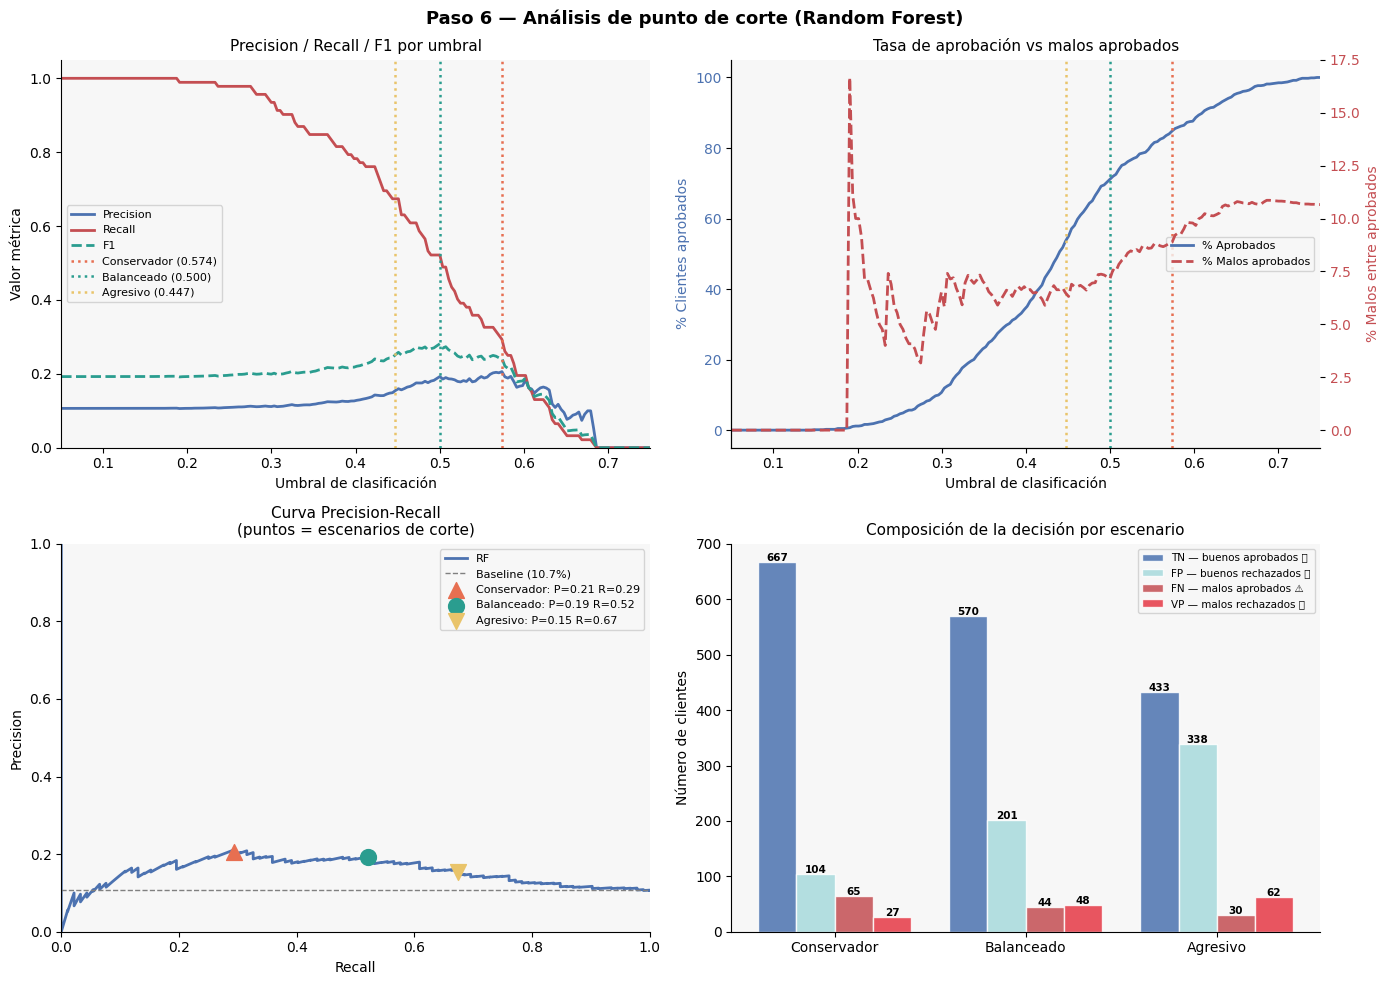

In [91]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualización
# ─────────────────────────────────────────────────────────────────────────────
 
COLOR_CONS = "#E76F51"
COLOR_BAL  = "#2A9D8F"
COLOR_AGR  = "#E9C46A"
COLORES_ESC = [COLOR_CONS, COLOR_BAL, COLOR_AGR]
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Paso 6 — Análisis de punto de corte (Random Forest)",
             fontsize=13, fontweight="bold")
 
# ── Panel 1: Precision / Recall / F1 vs umbral ───────────────────────────
ax = axes[0][0]
ax.plot(df_umbrales["umbral"], df_umbrales["precision"],
        color=COLOR_BUENO, linewidth=2, label="Precision")
ax.plot(df_umbrales["umbral"], df_umbrales["recall"],
        color=COLOR_MALO,  linewidth=2, label="Recall")
ax.plot(df_umbrales["umbral"], df_umbrales["f1"],
        color=COLOR_NEU,   linewidth=2, linestyle="--", label="F1")
 
for nombre, row, color in zip(escenarios, escenarios.values(), COLORES_ESC):
    ax.axvline(row["umbral"], color=color, linestyle=":",
               linewidth=1.8, label=f"{nombre} ({row['umbral']:.3f})")
 
ax.set_xlabel("Umbral de clasificación")
ax.set_ylabel("Valor métrica")
ax.set_title("Precision / Recall / F1 por umbral")
ax.legend(fontsize=8)
ax.set_xlim(0.05, 0.75)
ax.set_ylim(0, 1.05)
 
# ── Panel 2: Aprobación vs malos aprobados ────────────────────────────────
ax2      = axes[0][1]
ax2_twin = ax2.twinx()
 
ax2.plot(df_umbrales["umbral"],
         df_umbrales["tasa_aprobacion"] * 100,
         color=COLOR_BUENO, linewidth=2, label="% Aprobados")
ax2_twin.plot(df_umbrales["umbral"],
              df_umbrales["tasa_malo_aprobado"] * 100,
              color=COLOR_MALO, linewidth=2, linestyle="--",
              label="% Malos aprobados")
 
for nombre, row, color in zip(escenarios, escenarios.values(), COLORES_ESC):
    ax2.axvline(row["umbral"], color=color, linestyle=":", linewidth=1.8)
 
ax2.set_xlabel("Umbral de clasificación")
ax2.set_ylabel("% Clientes aprobados", color=COLOR_BUENO)
ax2_twin.set_ylabel("% Malos entre aprobados", color=COLOR_MALO)
ax2.tick_params(axis="y", labelcolor=COLOR_BUENO)
ax2_twin.tick_params(axis="y", labelcolor=COLOR_MALO)
ax2.set_title("Tasa de aprobación vs malos aprobados")
ax2.set_xlim(0.05, 0.75)
l1, lb1 = ax2.get_legend_handles_labels()
l2, lb2 = ax2_twin.get_legend_handles_labels()
ax2.legend(l1 + l2, lb1 + lb2, fontsize=8, loc="center right")
 
# ── Panel 3: Curva Precision-Recall con los 3 puntos ─────────────────────
ax3 = axes[1][0]
prec_c, rec_c, _ = precision_recall_curve(y_test, proba_rf)
ax3.plot(rec_c, prec_c, color=COLOR_BUENO, linewidth=2, label="RF")
ax3.axhline(TASA_TEST, color="gray", linestyle="--",
            linewidth=1, label=f"Baseline ({TASA_TEST:.1%})")
 
for nombre, row, color, marker in zip(
    escenarios, escenarios.values(),
    COLORES_ESC, ["^", "o", "v"]
):
    ax3.scatter(row["recall"], row["precision"],
                color=color, s=130, zorder=5, marker=marker,
                label=f"{nombre}: P={row['precision']:.2f} R={row['recall']:.2f}")
 
ax3.set_xlabel("Recall")
ax3.set_ylabel("Precision")
ax3.set_title("Curva Precision-Recall\n(puntos = escenarios de corte)")
ax3.legend(fontsize=8)
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
 
# ── Panel 4: Impacto operativo por escenario ─────────────────────────────
ax4 = axes[1][1]
nombres_esc = list(escenarios.keys())
x = np.arange(len(nombres_esc))
w = 0.2
 
tns = [escenarios[n]["tn"] for n in nombres_esc]
fps = [escenarios[n]["fp"] for n in nombres_esc]
fns = [escenarios[n]["fn"] for n in nombres_esc]
vps = [escenarios[n]["vp"] for n in nombres_esc]
 
ax4.bar(x - w*1.5, tns, width=w, label="TN — buenos aprobados ✅",
        color=COLOR_BUENO, alpha=0.85, edgecolor="white")
ax4.bar(x - w*0.5, fps, width=w, label="FP — buenos rechazados 💼",
        color="#A8DADC",   alpha=0.85, edgecolor="white")
ax4.bar(x + w*0.5, fns, width=w, label="FN — malos aprobados ⚠️",
        color=COLOR_MALO,  alpha=0.85, edgecolor="white")
ax4.bar(x + w*1.5, vps, width=w, label="VP — malos rechazados 🛡️",
        color="#E63946",   alpha=0.85, edgecolor="white")
 
for i in range(len(nombres_esc)):
    for val, offset in zip([tns[i], fps[i], fns[i], vps[i]],
                            [-w*1.5, -w*0.5, w*0.5, w*1.5]):
        ax4.text(i + offset, val + 2, str(int(val)),
                 ha="center", fontsize=7.5, fontweight="bold")
 
ax4.set_xticks(x)
ax4.set_xticklabels(nombres_esc)
ax4.set_ylabel("Número de clientes")
ax4.set_title("Composición de la decisión por escenario")
ax4.legend(fontsize=7.5)
 
plt.tight_layout()
plt.show()

In [92]:
# ─────────────────────────────────────────────────────────────────────────────
# Tabla ejecutiva de impacto
# ─────────────────────────────────────────────────────────────────────────────
 
print("═" * 68)
print("IMPACTO OPERATIVO POR ESCENARIO — 863 clientes en test")
print("═" * 68)
 
for nombre, row in escenarios.items():
    aprobados   = int(row["tn"] + row["fn"])
    rechazados  = int(row["fp"] + row["vp"])
    malos_apr   = int(row["fn"])
    buenos_rech = int(row["fp"])
    malos_rech  = int(row["vp"])
    reduccion   = (TASA_TEST - row["tasa_malo_aprobado"]) / TASA_TEST * 100
 
    print(f"\n  📌 {nombre.upper()}  (umbral = {row['umbral']:.4f})")
    print(f"  {'─'*58}")
    print(f"  Aprobados               : {aprobados:>4} ({aprobados/len(y_test):.1%})")
    print(f"  Rechazados              : {rechazados:>4} ({rechazados/len(y_test):.1%})")
    print(f"  ✅ Malos rechazados     : {malos_rech:>4} "
          f"({malos_rech/y_test.sum():.1%} de los malos reales)")
    print(f"  ⚠️  Malos aprobados     : {malos_apr:>4} "
          f"({malos_apr/y_test.sum():.1%} — riesgo crediticio)")
    print(f"  💼 Buenos rechazados    : {buenos_rech:>4} "
          f"({buenos_rech/(y_test==0).sum():.1%} — costo de oportunidad)")
    print(f"  📉 Reducción mora       : {reduccion:.1f}pp vs sin modelo")
 
print("\n" + "═" * 68)
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Recomendación final
# ─────────────────────────────────────────────────────────────────────────────
 
esc_rec    = escenarios["Balanceado"]
umbral_rec = esc_rec["umbral"]
reduccion  = (TASA_TEST - esc_rec["tasa_malo_aprobado"]) / TASA_TEST * 100
 
print("═" * 68)
print("✅ PUNTO DE CORTE RECOMENDADO — Random Forest")
print("═" * 68)
print(f"\n  Umbral     : {umbral_rec:.4f}")
print(f"  Precision  : {esc_rec['precision']:.4f}")
print(f"  Recall     : {esc_rec['recall']:.4f}")
print(f"  F1         : {esc_rec['f1']:.4f}")
print(f"  Aprobados  : {esc_rec['tasa_aprobacion']:.1%} de los solicitantes")
print(f"  Malos aprobados : {esc_rec['tasa_malo_aprobado']:.1%} "
      f"(vs {TASA_TEST:.1%} sin modelo)")
print(f"  Reducción mora  : {reduccion:.1f}% respecto a originación sin modelo")
print()
print("  JUSTIFICACIÓN:")
print(f"  El umbral {umbral_rec:.4f} maximiza el F1, equilibrando la detección")
print(f"  de incumplimientos (Recall={esc_rec['recall']:.2f}) con la precisión")
print(f"  del rechazo (Precision={esc_rec['precision']:.2f}).")
print(f"  Con este corte la tasa de malos entre aprobados baja de")
print(f"  {TASA_TEST:.1%} a {esc_rec['tasa_malo_aprobado']:.1%} —")
print(f"  una reducción del {reduccion:.1f}% en el riesgo de la cartera.")
print()
print("  NOTA PARA NEGOCIO:")
print("  Si el equipo comercial requiere mayor volumen de aprobación,")
print("  se puede evaluar el escenario Agresivo con el entendimiento")
print("  explícito del incremento en la tasa de malos aprobados.")
print("═" * 68)

════════════════════════════════════════════════════════════════════
IMPACTO OPERATIVO POR ESCENARIO — 863 clientes en test
════════════════════════════════════════════════════════════════════

  📌 CONSERVADOR  (umbral = 0.5741)
  ──────────────────────────────────────────────────────────
  Aprobados               :  732 (84.8%)
  Rechazados              :  131 (15.2%)
  ✅ Malos rechazados     :   27 (29.3% de los malos reales)
  ⚠️  Malos aprobados     :   65 (70.7% — riesgo crediticio)
  💼 Buenos rechazados    :  104 (13.5% — costo de oportunidad)
  📉 Reducción mora       : 16.7pp vs sin modelo

  📌 BALANCEADO  (umbral = 0.5003)
  ──────────────────────────────────────────────────────────
  Aprobados               :  614 (71.1%)
  Rechazados              :  249 (28.9%)
  ✅ Malos rechazados     :   48 (52.2% de los malos reales)
  ⚠️  Malos aprobados     :   44 (47.8% — riesgo crediticio)
  💼 Buenos rechazados    :  201 (26.1% — costo de oportunidad)
  📉 Reducción mora       : 32.8pp 

## Paso 7 — Curva KS y distribución de scores (Random Forest)
 
El **KS (Kolmogorov-Smirnov)** es la métrica operativa estándar en la
industria de crédito colombiana. Mide la **máxima separación** entre la
distribución acumulada de buenos y malos a lo largo del score.
 
### ¿Cómo se usa operativamente?
 
El equipo de Riesgo ordena la población de menor a mayor score
(menor score = mayor riesgo) y encuentra el punto donde la separación
entre buenos y malos es máxima. Ese punto orienta el corte operativo.
 
### Interpretación del KS
 
| KS | Interpretación |
|---|---|
| < 0.20 | Modelo débil — no recomendado para originación |
| 0.20 – 0.30 | Aceptable — útil con señal limitada en los datos |
| 0.30 – 0.40 | Bueno — estándar de la industria |
| > 0.40 | Muy bueno |
 
El modelo RF obtuvo **KS = 0.2767** — aceptable dado que el IV máximo
de las features disponibles es 0.103 y no se cuenta con variables de
bureau de crédito externo.

In [93]:
# ─────────────────────────────────────────────────────────────────────────────
# Distribución de scores buenos vs malos
# ─────────────────────────────────────────────────────────────────────────────
 
proba_rf  = resultados["RF"]["proba"]
umbral_rec = escenarios["Balanceado"]["umbral"]  # del Paso 6
 
# Separar scores por clase
scores_buenos = proba_rf[y_test == 0]
scores_malos  = proba_rf[y_test == 1]
 
print("DISTRIBUCIÓN DE SCORES — Random Forest")
print("═" * 52)
print(f"  {'Estadístico':<18} {'Buenos (0)':>12} {'Malos (1)':>12}")
print("  " + "─" * 44)
stats_b = pd.Series(scores_buenos).describe()
stats_m = pd.Series(scores_malos).describe()
for stat in ["mean", "std", "min", "25%", "50%", "75%", "max"]:
    print(f"  {stat:<18} {stats_b[stat]:>12.4f} {stats_m[stat]:>12.4f}")
print("═" * 52)
print(f"\n  Separación (media malos - media buenos): "
      f"{scores_malos.mean() - scores_buenos.mean():.4f}")

DISTRIBUCIÓN DE SCORES — Random Forest
════════════════════════════════════════════════════
  Estadístico          Buenos (0)    Malos (1)
  ────────────────────────────────────────────
  mean                     0.4375       0.4896
  std                      0.1167       0.1132
  min                      0.1465       0.1878
  25%                      0.3533       0.4248
  50%                      0.4337       0.5023
  75%                      0.5063       0.5822
  max                      0.7460       0.6841
════════════════════════════════════════════════════

  Separación (media malos - media buenos): 0.0521


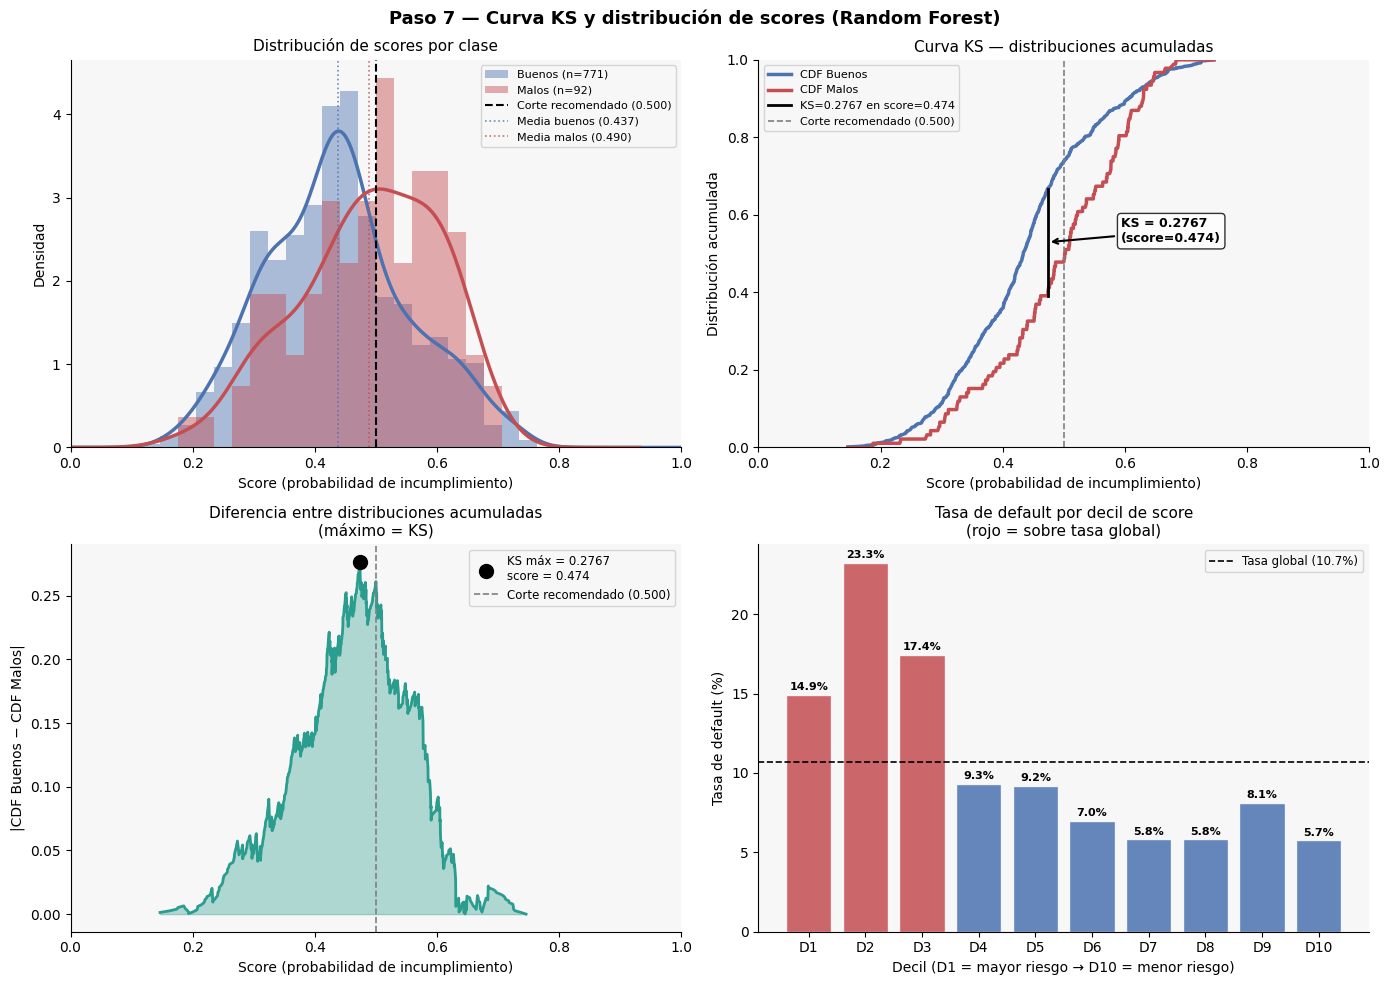


✓ KS = 0.2767 alcanzado en score = 0.474
  Corte recomendado (Paso 6): 0.5003


In [94]:
# ─────────────────────────────────────────────────────────────────────────────
# Curva KS y distribución de scores
# ─────────────────────────────────────────────────────────────────────────────
 
from sklearn.metrics import roc_curve
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Paso 7 — Curva KS y distribución de scores (Random Forest)",
             fontsize=13, fontweight="bold")
 
# ── Panel 1: Distribución de scores por clase (histograma + KDE) ──────────
ax = axes[0][0]
bins = np.linspace(0, 1, 35)
 
ax.hist(scores_buenos, bins=bins, alpha=0.45, color=COLOR_BUENO,
        density=True, label=f"Buenos (n={len(scores_buenos):,})",
        edgecolor="none")
ax.hist(scores_malos,  bins=bins, alpha=0.45, color=COLOR_MALO,
        density=True, label=f"Malos (n={len(scores_malos):,})",
        edgecolor="none")
 
pd.Series(scores_buenos).plot.kde(ax=ax, color=COLOR_BUENO, linewidth=2.5)
pd.Series(scores_malos).plot.kde( ax=ax, color=COLOR_MALO,  linewidth=2.5)
 
ax.axvline(umbral_rec, color="black", linestyle="--", linewidth=1.5,
           label=f"Corte recomendado ({umbral_rec:.3f})")
ax.axvline(scores_buenos.mean(), color=COLOR_BUENO, linestyle=":",
           linewidth=1.2, alpha=0.8,
           label=f"Media buenos ({scores_buenos.mean():.3f})")
ax.axvline(scores_malos.mean(), color=COLOR_MALO, linestyle=":",
           linewidth=1.2, alpha=0.8,
           label=f"Media malos ({scores_malos.mean():.3f})")
 
ax.set_xlabel("Score (probabilidad de incumplimiento)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de scores por clase")
ax.legend(fontsize=8)
ax.set_xlim(0, 1)
 
# ── Panel 2: Curva KS acumulada ───────────────────────────────────────────
ax2 = axes[0][1]
 
# Ordenar scores y calcular distribuciones acumuladas
scores_ordenados = np.sort(np.unique(proba_rf))
cdf_buenos = np.array([
    (scores_buenos <= s).mean() for s in scores_ordenados
])
cdf_malos = np.array([
    (scores_malos  <= s).mean() for s in scores_ordenados
])
 
diferencia = np.abs(cdf_buenos - cdf_malos)
idx_ks     = diferencia.argmax()
ks_score   = diferencia[idx_ks]
ks_umbral  = scores_ordenados[idx_ks]
 
ax2.plot(scores_ordenados, cdf_buenos, color=COLOR_BUENO,
         linewidth=2.5, label="CDF Buenos")
ax2.plot(scores_ordenados, cdf_malos,  color=COLOR_MALO,
         linewidth=2.5, label="CDF Malos")
 
# Flecha y anotación del KS
ax2.annotate(
    f"KS = {ks_score:.4f}\n(score={ks_umbral:.3f})",
    xy=(ks_umbral, (cdf_buenos[idx_ks] + cdf_malos[idx_ks]) / 2),
    xytext=(ks_umbral + 0.12, (cdf_buenos[idx_ks] + cdf_malos[idx_ks]) / 2),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    fontsize=9, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor="black", alpha=0.8)
)
 
# Segmento vertical del KS
ax2.plot([ks_umbral, ks_umbral],
         [cdf_buenos[idx_ks], cdf_malos[idx_ks]],
         color="black", linewidth=2, linestyle="-",
         label=f"KS={ks_score:.4f} en score={ks_umbral:.3f}")
 
ax2.axvline(umbral_rec, color="gray", linestyle="--",
            linewidth=1.2, label=f"Corte recomendado ({umbral_rec:.3f})")
 
ax2.set_xlabel("Score (probabilidad de incumplimiento)")
ax2.set_ylabel("Distribución acumulada")
ax2.set_title("Curva KS — distribuciones acumuladas")
ax2.legend(fontsize=8)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
 
# ── Panel 3: Diferencia KS por score ─────────────────────────────────────
ax3 = axes[1][0]
ax3.fill_between(scores_ordenados, diferencia,
                 alpha=0.35, color=COLOR_NEU)
ax3.plot(scores_ordenados, diferencia,
         color=COLOR_NEU, linewidth=2)
 
ax3.scatter(ks_umbral, ks_score, color="black", s=100, zorder=5,
            label=f"KS máx = {ks_score:.4f}\nscore = {ks_umbral:.3f}")
ax3.axvline(umbral_rec, color="gray", linestyle="--", linewidth=1.2,
            label=f"Corte recomendado ({umbral_rec:.3f})")
 
ax3.set_xlabel("Score (probabilidad de incumplimiento)")
ax3.set_ylabel("|CDF Buenos − CDF Malos|")
ax3.set_title("Diferencia entre distribuciones acumuladas\n(máximo = KS)")
ax3.legend(fontsize=8.5)
ax3.set_xlim(0, 1)
 
# ── Panel 4: % malos acumulados por decil de score ───────────────────────
ax4 = axes[1][1]
 
df_score = pd.DataFrame({
    "score" : proba_rf,
    "target": y_test.values
}).sort_values("score", ascending=False).reset_index(drop=True)
 
df_score["decil"] = pd.qcut(
    df_score.index, q=10,
    labels=[f"D{i}" for i in range(1, 11)]
)
 
decil_stats = (df_score.groupby("decil", observed=True)
               .agg(
                   n         = ("target", "count"),
                   n_malos   = ("target", "sum"),
                   score_min = ("score",  "min"),
                   score_max = ("score",  "max"),
               )
               .assign(
                   tasa_malo       = lambda x: x["n_malos"] / x["n"],
                   pct_malos_captu = lambda x: x["n_malos"].cumsum() / x["n_malos"].sum(),
               )
               .reset_index())
 
colores_dec = [COLOR_MALO if t > TASA_TEST else COLOR_BUENO
               for t in decil_stats["tasa_malo"]]
 
bars = ax4.bar(decil_stats["decil"], decil_stats["tasa_malo"] * 100,
               color=colores_dec, edgecolor="white", linewidth=1, alpha=0.85)
 
ax4.axhline(TASA_TEST * 100, color="black", linestyle="--",
            linewidth=1.2, label=f"Tasa global ({TASA_TEST:.1%})")
 
for bar, (_, row) in zip(bars, decil_stats.iterrows()):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f"{row['tasa_malo']:.1%}",
             ha="center", fontsize=8, fontweight="bold")
 
ax4.set_xlabel("Decil (D1 = mayor riesgo → D10 = menor riesgo)")
ax4.set_ylabel("Tasa de default (%)")
ax4.set_title("Tasa de default por decil de score\n(rojo = sobre tasa global)")
ax4.legend(fontsize=8.5)
 
plt.tight_layout()
plt.show()
 
print(f"\n✓ KS = {ks_score:.4f} alcanzado en score = {ks_umbral:.3f}")
print(f"  Corte recomendado (Paso 6): {umbral_rec:.4f}")

In [95]:
# ─────────────────────────────────────────────────────────────────────────────
# Tabla decil detallada (formato ejecutivo)
# ─────────────────────────────────────────────────────────────────────────────
 
print("═" * 80)
print("TABLA KS POR DECIL — Random Forest (ordenado de mayor a menor riesgo)")
print("═" * 80)
print(f"  {'Decil':<6} {'Score min':>10} {'Score max':>10} {'n':>6} "
      f"{'n_malos':>8} {'Tasa malo':>10} {'% Malos capturado':>18} "
      f"{'% Aprob. acum.':>15}")
print("  " + "─" * 76)
 
pct_aprobacion_acum = 0
for _, row in decil_stats.iterrows():
    pct_aprobacion_acum += row["n"] / len(proba_rf)
    flag = " ←" if row["tasa_malo"] > TASA_TEST else ""
    print(f"  {row['decil']:<6} {row['score_max']:>10.4f} {row['score_min']:>10.4f} "
          f"{int(row['n']):>6} {int(row['n_malos']):>8} "
          f"{row['tasa_malo']:>9.1%}  "
          f"{row['pct_malos_captu']:>17.1%} "
          f"{pct_aprobacion_acum:>14.1%}{flag}")
 
print("═" * 80)
print(f"\n  Referencia: tasa global de default = {TASA_TEST:.2%}")
print(f"  '← ' indica deciles con tasa de malo sobre la tasa global")
print(f"\n  Lectura operativa:")
print(f"  Rechazando D1 (top 10% de mayor riesgo) se captura el "
      f"{decil_stats.iloc[0]['pct_malos_captu']:.1%} de los malos")
print(f"  Rechazando D1+D2 (top 20%) se captura el "
      f"{decil_stats.iloc[1]['pct_malos_captu']:.1%} de los malos")
print(f"  aprobando el {1 - 0.2:.0%} restante de los solicitantes.")

════════════════════════════════════════════════════════════════════════════════
TABLA KS POR DECIL — Random Forest (ordenado de mayor a menor riesgo)
════════════════════════════════════════════════════════════════════════════════
  Decil   Score min  Score max      n  n_malos  Tasa malo  % Malos capturado  % Aprob. acum.
  ────────────────────────────────────────────────────────────────────────────
  D1         0.7460     0.6098     87       13     14.9%              14.1%          10.1% ←
  D2         0.6093     0.5475     86       20     23.3%              35.9%          20.0% ←
  D3         0.5475     0.4953     86       15     17.4%              52.2%          30.0% ←
  D4         0.4949     0.4625     86        8      9.3%              60.9%          40.0%
  D5         0.4622     0.4398     87        8      9.2%              69.6%          50.1%
  D6         0.4395     0.4153     86        6      7.0%              76.1%          60.0%
  D7         0.4153     0.3797     86       

## Paso 8 — Importancia de variables (Random Forest)
 
Random Forest permite extraer la importancia de cada variable a través
de tres métodos complementarios:
 
| Método | Qué mide | Ventaja | Limitación |
|---|---|---|---|
| **Impurity (Gini)** | Reducción promedio de impureza en splits | Rápido, nativo | Favorece variables con muchos valores únicos |
| **Permutation importance** | Degradación del AUC al permutar aleatoriamente cada variable | Más robusto, basado en métricas reales | Más lento |
| **SHAP values** | Contribución marginal de cada variable a cada predicción | Interpretable a nivel de cliente | Requiere librería adicional |
 
Se calculan los dos primeros. Juntos dan una visión más confiable
que cualquiera por separado — si una variable es importante en ambos,
la evidencia es sólida.

In [96]:
# ─────────────────────────────────────────────────────────────────────────────
# Importancia por Gini (nativa del RF)
# ─────────────────────────────────────────────────────────────────────────────
 
from sklearn.inspection import permutation_importance
 
# Extraer el modelo RF del dict de modelos tuneados
rf_model = modelos_tuned["RF"]
 
# Importancia por Gini (feature_importances_ del RF)
importancias_gini = pd.DataFrame({
    "feature"   : FEATURES,
    "importancia": rf_model.feature_importances_,
}).sort_values("importancia", ascending=False).reset_index(drop=True)
 
importancias_gini["importancia_pct"] = (
    importancias_gini["importancia"] /
    importancias_gini["importancia"].sum() * 100
)
importancias_gini["importancia_acum"] = (
    importancias_gini["importancia_pct"].cumsum()
)
 
print("IMPORTANCIA POR GINI (reducción de impureza)")
print("═" * 58)
print(f"  {'Feature':<32} {'Importancia':>12} {'% Acum.':>8}")
print("  " + "─" * 54)
for _, row in importancias_gini.iterrows():
    bar = "█" * int(row["importancia_pct"] / 2)
    print(f"  {row['feature']:<32} {row['importancia_pct']:>10.2f}%  "
          f"{row['importancia_acum']:>6.1f}%  {bar}")
print("═" * 58)

IMPORTANCIA POR GINI (reducción de impureza)
══════════════════════════════════════════════════════════
  Feature                           Importancia  % Acum.
  ──────────────────────────────────────────────────────
  PORCEND                               23.66%    23.7%  ███████████
  Edad                                  17.91%    41.6%  ████████
  log_tiempo_sistema                    16.75%    58.3%  ████████
  log_tiempo_cliente                    16.29%    74.6%  ████████
  woe_estado_civil_agrup                 8.55%    83.2%  ████
  TiempoActividadAnios                   8.48%    91.6%  ████
  woe_nivel_academico_agrup              7.99%    99.6%  ███
  capacidad_pago                         0.38%   100.0%  
══════════════════════════════════════════════════════════


In [97]:
# ─────────────────────────────────────────────────────────────────────────────
# Permutation Importance (más robusto)
# ─────────────────────────────────────────────────────────────────────────────
 
print("Calculando Permutation Importance sobre test...")
print("(puede tardar ~30 segundos)\n")
 
perm_result = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats    = 30,       # 30 permutaciones por variable — estable
    scoring      = "roc_auc",
    random_state = 42,
    n_jobs       = -1,
)
 
importancias_perm = pd.DataFrame({
    "feature"        : FEATURES,
    "importancia_mean": perm_result.importances_mean,
    "importancia_std" : perm_result.importances_std,
}).sort_values("importancia_mean", ascending=False).reset_index(drop=True)
 
print("PERMUTATION IMPORTANCE (degradación AUC al permutar)")
print("═" * 62)
print(f"  {'Feature':<32} {'Mean':>8} {'Std':>7}  Interpretación")
print("  " + "─" * 58)
for _, row in importancias_perm.iterrows():
    if row["importancia_mean"] > 0.005:
        interp = "✅ Relevante"
    elif row["importancia_mean"] > 0:
        interp = "⚠️  Débil"
    else:
        interp = "❌ Sin aporte"
    print(f"  {row['feature']:<32} {row['importancia_mean']:>8.4f} "
          f"±{row['importancia_std']:>6.4f}  {interp}")
print("═" * 62)
print("\n  Nota: importancia_mean = cuánto baja el AUC al permutar la variable")
print("  Una variable con importancia ≈ 0 no aporta al modelo en test")

Calculando Permutation Importance sobre test...
(puede tardar ~30 segundos)

PERMUTATION IMPORTANCE (degradación AUC al permutar)
══════════════════════════════════════════════════════════════
  Feature                              Mean     Std  Interpretación
  ──────────────────────────────────────────────────────────
  log_tiempo_sistema                 0.0411 ±0.0206  ✅ Relevante
  woe_nivel_academico_agrup          0.0270 ±0.0096  ✅ Relevante
  log_tiempo_cliente                 0.0203 ±0.0120  ✅ Relevante
  PORCEND                            0.0187 ±0.0117  ✅ Relevante
  TiempoActividadAnios               0.0102 ±0.0071  ✅ Relevante
  woe_estado_civil_agrup             0.0005 ±0.0085  ⚠️  Débil
  Edad                               0.0003 ±0.0099  ⚠️  Débil
  capacidad_pago                    -0.0003 ±0.0003  ❌ Sin aporte
══════════════════════════════════════════════════════════════

  Nota: importancia_mean = cuánto baja el AUC al permutar la variable
  Una variable con importan

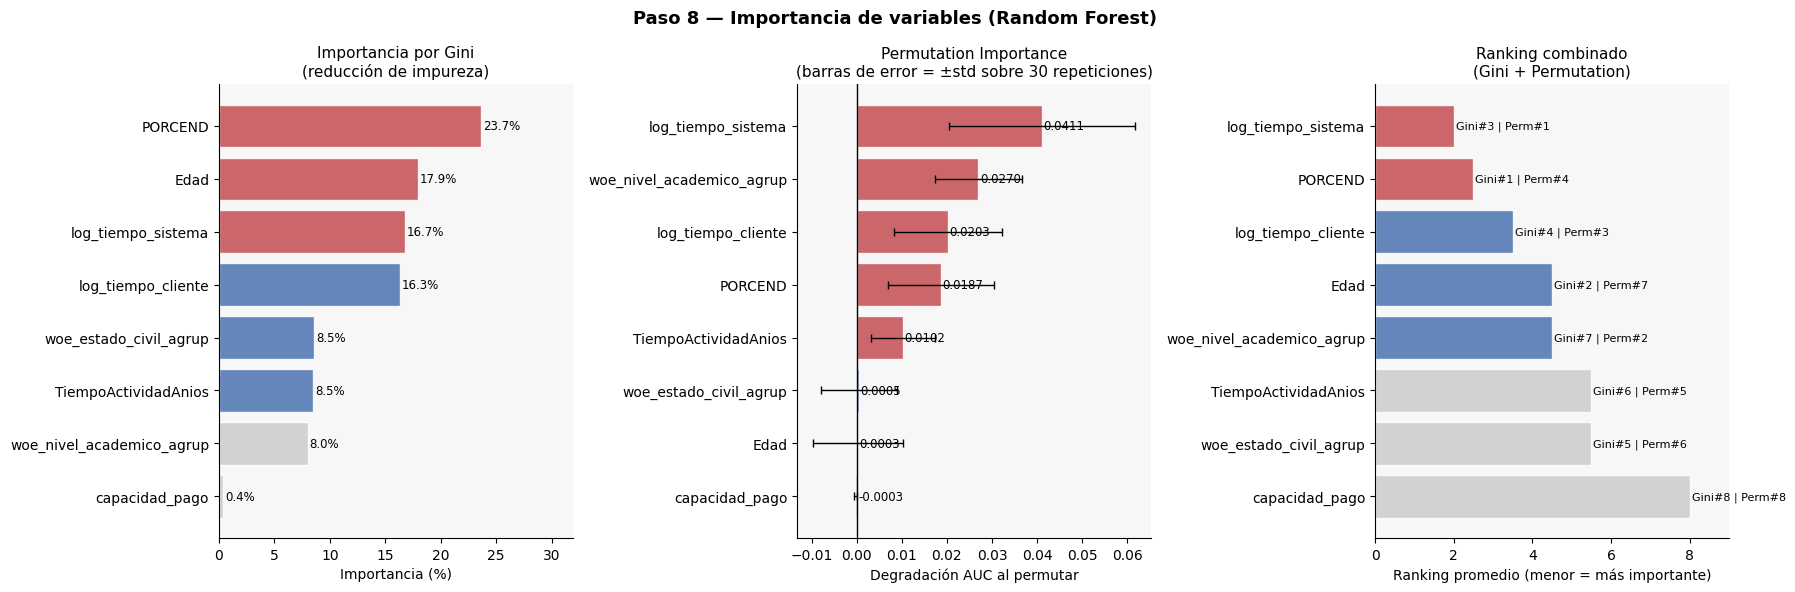

In [98]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualización comparativa Gini vs Permutation
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Paso 8 — Importancia de variables (Random Forest)",
             fontsize=13, fontweight="bold")
 
# ── Panel 1: Importancia Gini ─────────────────────────────────────────────
ax = axes[0]
colores_gini = [COLOR_MALO if i < 3 else COLOR_BUENO if i < 6 else "#CCCCCC"
                for i in range(len(importancias_gini))]
bars = ax.barh(importancias_gini["feature"],
               importancias_gini["importancia_pct"],
               color=colores_gini, edgecolor="white",
               linewidth=1, alpha=0.85)
 
for bar, (_, row) in zip(bars, importancias_gini.iterrows()):
    ax.text(row["importancia_pct"] + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f"{row['importancia_pct']:.1f}%",
            va="center", fontsize=8.5)
 
ax.set_xlabel("Importancia (%)")
ax.set_title("Importancia por Gini\n(reducción de impureza)")
ax.invert_yaxis()
ax.set_xlim(0, importancias_gini["importancia_pct"].max() * 1.35)
 
# ── Panel 2: Permutation Importance con barras de error ──────────────────
ax2 = axes[1]
colores_perm = [COLOR_MALO if m > 0.005 else
                COLOR_BUENO if m > 0 else "#CCCCCC"
                for m in importancias_perm["importancia_mean"]]
 
bars2 = ax2.barh(importancias_perm["feature"],
                 importancias_perm["importancia_mean"],
                 xerr=importancias_perm["importancia_std"],
                 color=colores_perm, edgecolor="white",
                 linewidth=1, alpha=0.85,
                 error_kw=dict(ecolor="black", capsize=3, linewidth=1))
 
ax2.axvline(0, color="black", linewidth=1)
for bar, (_, row) in zip(bars2, importancias_perm.iterrows()):
    ax2.text(max(row["importancia_mean"], 0) + 0.0003,
             bar.get_y() + bar.get_height() / 2,
             f"{row['importancia_mean']:.4f}",
             va="center", fontsize=8.5)
 
ax2.set_xlabel("Degradación AUC al permutar")
ax2.set_title("Permutation Importance\n(barras de error = ±std sobre 30 repeticiones)")
ax2.invert_yaxis()
 
# ── Panel 3: Ranking combinado (promedio de rangos) ───────────────────────
ax3 = axes[2]
 
# Rank de cada variable en cada método (1 = más importante)
rank_gini = importancias_gini.set_index("feature")["importancia"].rank(
    ascending=False)
rank_perm = importancias_perm.set_index("feature")["importancia_mean"].rank(
    ascending=False)
 
df_rank = pd.DataFrame({
    "rank_gini": rank_gini,
    "rank_perm": rank_perm,
}).assign(rank_promedio=lambda x: (x["rank_gini"] + x["rank_perm"]) / 2
).sort_values("rank_promedio")
 
colores_rank = [COLOR_MALO if r <= 3 else COLOR_BUENO if r <= 5 else "#CCCCCC"
                for r in df_rank["rank_promedio"]]
 
bars3 = ax3.barh(df_rank.index, df_rank["rank_promedio"],
                 color=colores_rank, edgecolor="white",
                 linewidth=1, alpha=0.85)
 
for bar, (feat, row) in zip(bars3, df_rank.iterrows()):
    ax3.text(row["rank_promedio"] + 0.05,
             bar.get_y() + bar.get_height() / 2,
             f"Gini#{int(row['rank_gini'])} | Perm#{int(row['rank_perm'])}",
             va="center", fontsize=8)
 
ax3.set_xlabel("Ranking promedio (menor = más importante)")
ax3.set_title("Ranking combinado\n(Gini + Permutation)")
ax3.invert_yaxis()
ax3.set_xlim(0, len(FEATURES) + 1)
 
plt.tight_layout()
plt.show()

In [99]:
# ─────────────────────────────────────────────────────────────────────────────
# Tabla resumen y variables candidatas a eliminar
# ─────────────────────────────────────────────────────────────────────────────
 
df_importancia_final = (df_rank
    .reset_index()
    .rename(columns={"index": "feature"})
    .merge(importancias_gini[["feature", "importancia_pct"]], on="feature")
    .merge(importancias_perm[["feature", "importancia_mean"]], on="feature")
    .sort_values("rank_promedio")
    .reset_index(drop=True))
 
print("═" * 78)
print("RANKING FINAL COMBINADO — Importancia de variables en RF")
print("═" * 78)
print(f"  {'#':<4} {'Feature':<32} {'Gini%':>7} {'Perm AUC':>9} "
      f"{'Rk Gini':>8} {'Rk Perm':>8} {'Rk Prom':>8}")
print("  " + "─" * 74)
 
for i, (_, row) in enumerate(df_importancia_final.iterrows(), 1):
    estado = "🔴" if i <= 3 else "🟡" if i <= 5 else "⚪"
    print(f"  {estado} {i:<3} {row['feature']:<32} "
          f"{row['importancia_pct']:>6.1f}% "
          f"{row['importancia_mean']:>9.4f} "
          f"{int(row['rank_gini']):>8} "
          f"{int(row['rank_perm']):>8} "
          f"{row['rank_promedio']:>8.1f}")
 
print("═" * 78)
print("\n  🔴 Top 3   — variables críticas del modelo")
print("  🟡 Top 4-5 — variables de soporte relevante")
print("  ⚪ Resto   — aporte débil, candidatas a simplificar en producción")
 
# Identificar variables con permutation importance ≈ 0
sin_aporte = df_importancia_final[
    df_importancia_final["importancia_mean"] <= 0
]["feature"].tolist()
 
if sin_aporte:
    print(f"\n  ⚠️  Variables con Permutation Importance ≤ 0:")
    for f in sin_aporte:
        print(f"      → {f}  (no mejora el AUC — candidata a excluir en v2)")

══════════════════════════════════════════════════════════════════════════════
RANKING FINAL COMBINADO — Importancia de variables en RF
══════════════════════════════════════════════════════════════════════════════
  #    Feature                            Gini%  Perm AUC  Rk Gini  Rk Perm  Rk Prom
  ──────────────────────────────────────────────────────────────────────────
  🔴 1   log_tiempo_sistema                 16.7%    0.0411        3        1      2.0
  🔴 2   PORCEND                            23.7%    0.0187        1        4      2.5
  🔴 3   log_tiempo_cliente                 16.3%    0.0203        4        3      3.5
  🟡 4   Edad                               17.9%    0.0003        2        7      4.5
  🟡 5   woe_nivel_academico_agrup           8.0%    0.0270        7        2      4.5
  ⚪ 6   TiempoActividadAnios                8.5%    0.0102        6        5      5.5
  ⚪ 7   woe_estado_civil_agrup              8.5%    0.0005        5        6      5.5
  ⚪ 8   capacidad_pag

## Paso 9 — Scorecard por decil (Random Forest)
 
El scorecard por decil es el **entregable operativo principal** para los
equipos de Riesgo y Negocio. Traduce el score probabilístico del modelo
en una tabla accionable que responde dos preguntas clave:
 
- **Riesgo:** ¿qué tan malo es cada segmento de la población?
- **Volumen:** ¿cuántos clientes apruebo si fijo el corte en este decil?
 
### Convención de ordenamiento
- **D1 = mayor riesgo** (score más alto → más probable que incumpla)
- **D10 = menor riesgo** (score más bajo → más probable que pague)
 
El equipo de Riesgo "rechaza desde arriba": define cuántos deciles de
alto riesgo rechaza y aprueba el resto.
 
### Métricas del scorecard
 
| Métrica | Definición |
|---|---|
| **Tasa de malo** | % de clientes en el decil que incumplen |
| **% Malos capturados** | De todos los malos, qué % cayó en este decil |
| **% Malos acumulados** | Captura acumulada rechazando hasta este decil |
| **Lift** | Tasa malo del decil / Tasa malo global — cuántas veces mejor que aleatorio |
| **% Aprobados acumulados** | Volumen aprobado si el corte se pone aquí |

In [100]:
# ─────────────────────────────────────────────────────────────────────────────
# Construcción del scorecard
# ─────────────────────────────────────────────────────────────────────────────
 
proba_rf   = resultados["RF"]["proba"]
umbral_rec = escenarios["Balanceado"]["umbral"]   # del Paso 6
TASA_TEST  = y_test.mean()
 
# Construir DataFrame de scores ordenado de mayor a menor riesgo
df_score = pd.DataFrame({
    "score" : proba_rf,
    "target": y_test.values,
}).sort_values("score", ascending=False).reset_index(drop=True)
 
# Asignar decil (D1 = mayor riesgo)
df_score["decil"] = pd.qcut(
    df_score.index,
    q      = 10,
    labels = [f"D{i}" for i in range(1, 11)]
)
 
# Calcular métricas por decil
total_malos  = df_score["target"].sum()
total_buenos = (df_score["target"] == 0).sum()
total_n      = len(df_score)
 
scorecard = []
for decil, grupo in df_score.groupby("decil", observed=True):
    n          = len(grupo)
    n_malos    = grupo["target"].sum()
    n_buenos   = n - n_malos
    tasa_malo  = n_malos / n
    scorecard.append({
        "Decil"          : decil,
        "Score máx"      : grupo["score"].max(),
        "Score mín"      : grupo["score"].min(),
        "Score mediana"  : grupo["score"].median(),
        "n"              : n,
        "n_buenos"       : int(n_buenos),
        "n_malos"        : int(n_malos),
        "Tasa malo"      : tasa_malo,
        "Lift"           : tasa_malo / TASA_TEST,
        "% Malos decil"  : n_malos / total_malos,
    })
 
df_sc = pd.DataFrame(scorecard)
 
# Acumulados (rechazando desde D1)
df_sc["% Malos capturados acum"] = df_sc["n_malos"].cumsum() / total_malos
df_sc["% Volumen rechazado acum"]= df_sc["n"].cumsum() / total_n
df_sc["% Volumen aprobado acum"] = 1 - df_sc["% Volumen rechazado acum"]
 
# Marcar decil de corte recomendado
df_sc["corte"] = df_sc.apply(
    lambda r: "← CORTE" if (r["Score mín"] <= umbral_rec <= r["Score máx"])
              else "", axis=1
)
 
# Imprimir scorecard
print("═" * 105)
print("SCORECARD POR DECIL — Random Forest (D1=mayor riesgo → D10=menor riesgo)")
print("═" * 105)
print(f"  {'Decil':<6} {'Score máx':>10} {'Score mín':>10} {'n':>6} "
      f"{'n_malos':>8} {'Tasa malo':>10} {'Lift':>6} "
      f"{'% Malos acum':>13} {'% Aprobados':>12}  Corte")
print("  " + "─" * 100)
 
for _, row in df_sc.iterrows():
    flag_riesgo = "🔴" if row["Tasa malo"] > TASA_TEST * 2 else \
                  "🟡" if row["Tasa malo"] > TASA_TEST else "🟢"
    print(f"  {flag_riesgo} {row['Decil']:<5} "
          f"{row['Score máx']:>10.4f} {row['Score mín']:>10.4f} "
          f"{int(row['n']):>6} {int(row['n_malos']):>8} "
          f"{row['Tasa malo']:>9.1%}  {row['Lift']:>5.2f}x "
          f"{row['% Malos capturados acum']:>12.1%} "
          f"{row['% Volumen aprobado acum']:>11.1%}  {row['corte']}")
 
print("═" * 105)
print(f"\n  Tasa global de default (test): {TASA_TEST:.2%}")
print(f"  Lift = Tasa malo del decil / Tasa global")
print(f"  🔴 Tasa malo > 2x global  |  🟡 Tasa malo > global  |  🟢 Tasa malo < global")

═════════════════════════════════════════════════════════════════════════════════════════════════════════
SCORECARD POR DECIL — Random Forest (D1=mayor riesgo → D10=menor riesgo)
═════════════════════════════════════════════════════════════════════════════════════════════════════════
  Decil   Score máx  Score mín      n  n_malos  Tasa malo   Lift  % Malos acum  % Aprobados  Corte
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  🟡 D1        0.7460     0.6098     87       13     14.9%   1.40x        14.1%       89.9%  
  🔴 D2        0.6093     0.5475     86       20     23.3%   2.18x        35.9%       80.0%  
  🟡 D3        0.5475     0.4953     86       15     17.4%   1.64x        52.2%       70.0%  ← CORTE
  🟢 D4        0.4949     0.4625     86        8      9.3%   0.87x        60.9%       60.0%  
  🟢 D5        0.4622     0.4398     87        8      9.2%   0.86x        69.6%       49.9%  
  🟢 D6        0.4395     0.4153     86   

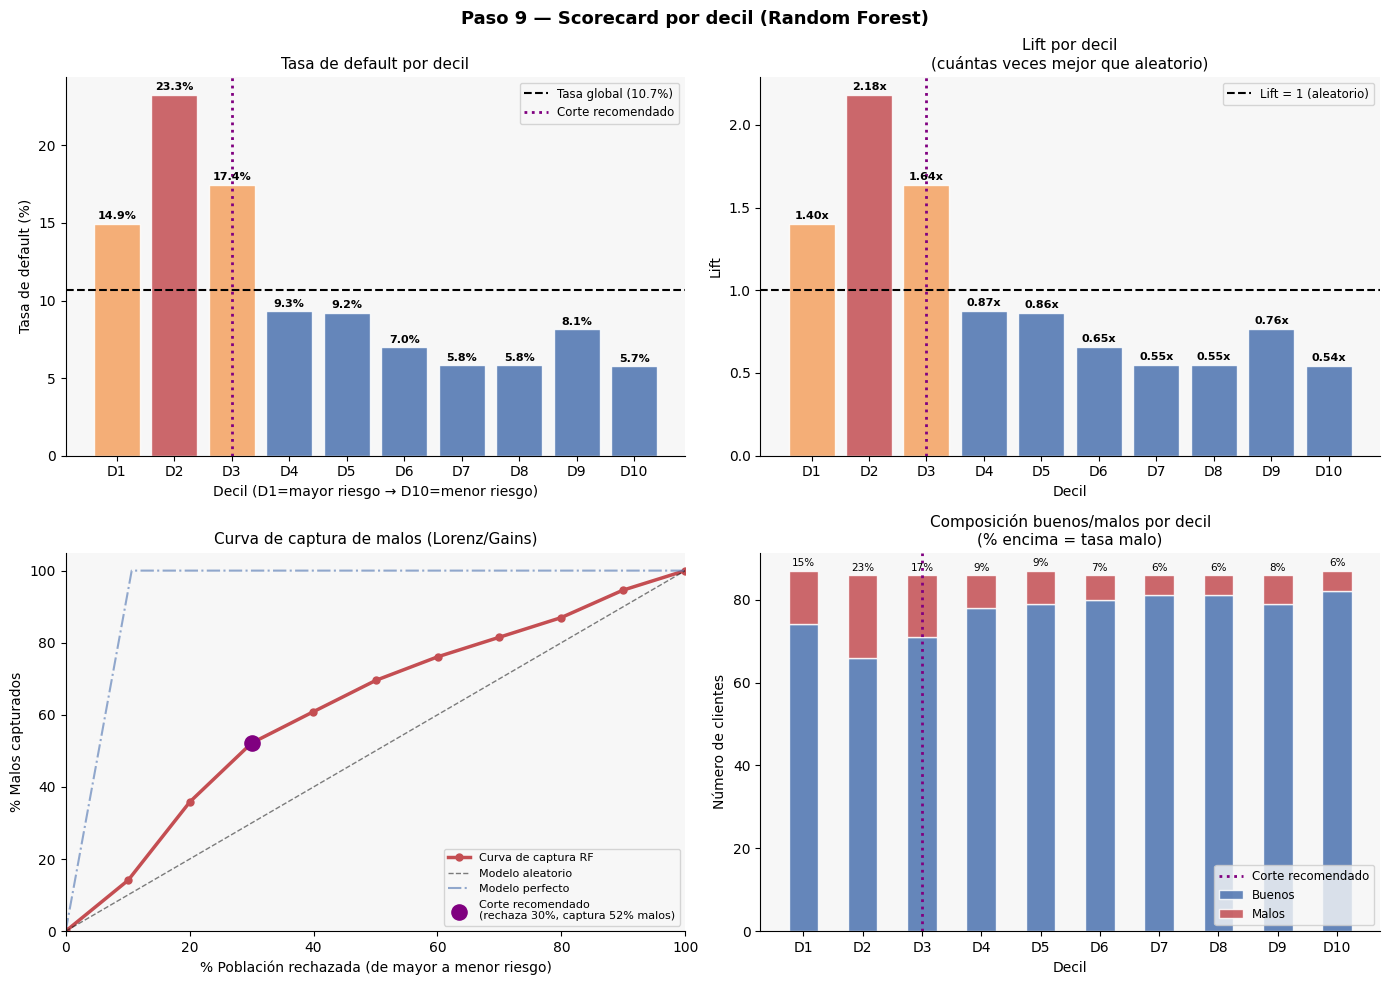

In [101]:
# ─────────────────────────────────────────────────────────────────────────────
# Visualización del scorecard
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Paso 9 — Scorecard por decil (Random Forest)",
             fontsize=13, fontweight="bold")
 
deciles   = df_sc["Decil"].astype(str)
idx_corte = df_sc[df_sc["corte"] != ""].index
 
# ── Panel 1: Tasa de malo por decil ──────────────────────────────────────
ax = axes[0][0]
colores_tasa = [
    COLOR_MALO  if t > TASA_TEST * 2 else
    "#F4A261"   if t > TASA_TEST else
    COLOR_BUENO
    for t in df_sc["Tasa malo"]
]
bars = ax.bar(deciles, df_sc["Tasa malo"] * 100,
              color=colores_tasa, edgecolor="white",
              linewidth=1, alpha=0.85)
 
ax.axhline(TASA_TEST * 100, color="black", linestyle="--",
           linewidth=1.5, label=f"Tasa global ({TASA_TEST:.1%})")
 
# Marcar decil de corte
if len(idx_corte) > 0:
    ax.axvline(idx_corte[0], color="purple", linestyle=":",
               linewidth=2, label=f"Corte recomendado")
 
for bar, (_, row) in zip(bars, df_sc.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{row['Tasa malo']:.1%}",
            ha="center", fontsize=8, fontweight="bold")
 
ax.set_xlabel("Decil (D1=mayor riesgo → D10=menor riesgo)")
ax.set_ylabel("Tasa de default (%)")
ax.set_title("Tasa de default por decil")
ax.legend(fontsize=8.5)
 
# ── Panel 2: Lift por decil ───────────────────────────────────────────────
ax2 = axes[0][1]
colores_lift = [COLOR_MALO if l > 2 else "#F4A261" if l > 1 else COLOR_BUENO
                for l in df_sc["Lift"]]
bars2 = ax2.bar(deciles, df_sc["Lift"],
                color=colores_lift, edgecolor="white",
                linewidth=1, alpha=0.85)
ax2.axhline(1, color="black", linestyle="--", linewidth=1.5,
            label="Lift = 1 (aleatorio)")
 
if len(idx_corte) > 0:
    ax2.axvline(idx_corte[0], color="purple", linestyle=":",
                linewidth=2)
 
for bar, (_, row) in zip(bars2, df_sc.iterrows()):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.03,
             f"{row['Lift']:.2f}x",
             ha="center", fontsize=8, fontweight="bold")
 
ax2.set_xlabel("Decil")
ax2.set_ylabel("Lift")
ax2.set_title("Lift por decil\n(cuántas veces mejor que aleatorio)")
ax2.legend(fontsize=8.5)
 
# ── Panel 3: Curva de captura de malos (Lorenz) ───────────────────────────
ax3 = axes[1][0]
x_pct  = np.insert(df_sc["% Volumen rechazado acum"].values, 0, 0)
y_pct  = np.insert(df_sc["% Malos capturados acum"].values, 0, 0)
 
ax3.plot(x_pct * 100, y_pct * 100,
         color=COLOR_MALO, linewidth=2.5,
         marker="o", markersize=5, label="Curva de captura RF")
ax3.plot([0, 100], [0, 100], "k--", linewidth=1,
         alpha=0.5, label="Modelo aleatorio")
ax3.plot([0, TASA_TEST * 100, 100],
         [0, 100, 100], color=COLOR_BUENO,
         linewidth=1.5, linestyle="-.",
         label="Modelo perfecto", alpha=0.6)
 
# Marcar corte
if len(idx_corte) > 0:
    i_c  = idx_corte[0]
    ax3.scatter(
        x_pct[i_c + 1] * 100,
        y_pct[i_c + 1] * 100,
        color="purple", s=120, zorder=5,
        label=f"Corte recomendado\n"
              f"(rechaza {x_pct[i_c+1]:.0%}, captura {y_pct[i_c+1]:.0%} malos)"
    )
 
ax3.set_xlabel("% Población rechazada (de mayor a menor riesgo)")
ax3.set_ylabel("% Malos capturados")
ax3.set_title("Curva de captura de malos (Lorenz/Gains)")
ax3.legend(fontsize=8)
ax3.set_xlim(0, 100)
ax3.set_ylim(0, 105)
 
# ── Panel 4: Composición buenos/malos por decil ───────────────────────────
ax4 = axes[1][1]
w   = 0.5
ax4.bar(deciles, df_sc["n_buenos"], width=w,
        color=COLOR_BUENO, alpha=0.85, label="Buenos",
        edgecolor="white")
ax4.bar(deciles, df_sc["n_malos"], width=w,
        bottom=df_sc["n_buenos"],
        color=COLOR_MALO, alpha=0.85, label="Malos",
        edgecolor="white")
 
if len(idx_corte) > 0:
    ax4.axvline(idx_corte[0], color="purple", linestyle=":",
                linewidth=2, label="Corte recomendado")
 
for i, (_, row) in enumerate(df_sc.iterrows()):
    ax4.text(i, row["n"] + 1,
             f"{row['Tasa malo']:.0%}",
             ha="center", fontsize=7.5, color="black")
 
ax4.set_xlabel("Decil")
ax4.set_ylabel("Número de clientes")
ax4.set_title("Composición buenos/malos por decil\n(% encima = tasa malo)")
ax4.legend(fontsize=8.5)
 
plt.tight_layout()
plt.show()

In [102]:
# ─────────────────────────────────────────────────────────────────────────────
# Resumen ejecutivo del scorecard
# ─────────────────────────────────────────────────────────────────────────────
 
# Encontrar el decil donde cae el corte recomendado
decil_corte = df_sc[df_sc["corte"] != ""].iloc[0] if len(idx_corte) > 0 \
              else df_sc.iloc[3]
 
n_deciles_rechazados = df_sc[
    df_sc["Score mín"] >= umbral_rec
].shape[0]
if n_deciles_rechazados == 0:
    n_deciles_rechazados = int(
        df_sc["% Volumen rechazado acum"].searchsorted(0.20) + 1
    )
 
pct_malos_capturados = df_sc.iloc[n_deciles_rechazados - 1]["% Malos capturados acum"]
pct_volumen_rechazado = df_sc.iloc[n_deciles_rechazados - 1]["% Volumen rechazado acum"]
pct_volumen_aprobado  = 1 - pct_volumen_rechazado
 
print("═" * 68)
print("RESUMEN EJECUTIVO — Scorecard por Decil")
print("═" * 68)
print(f"\n  Modelo            : Random Forest (KS={resultados['RF']['KS']:.4f})")
print(f"  Umbral recomendado: {umbral_rec:.4f} (escenario Balanceado)")
print(f"  Tasa default real : {TASA_TEST:.2%}")
print()
print(f"  ESTRATEGIA DE RECHAZO:")
print(f"  Rechazando los {n_deciles_rechazados} decile(s) de mayor riesgo:")
print(f"    → Se rechaza el {pct_volumen_rechazado:.1%} del volumen total")
print(f"    → Se aprueba el {pct_volumen_aprobado:.1%} del volumen total")
print(f"    → Se captura el {pct_malos_capturados:.1%} de los malos reales")
print()
 
# Lift de los deciles rechazados
lift_top = df_sc.iloc[:n_deciles_rechazados]["Tasa malo"].mean() / TASA_TEST
print(f"  EFICIENCIA DEL RECHAZO:")
print(f"    Tasa malo media en deciles rechazados: "
      f"{df_sc.iloc[:n_deciles_rechazados]['Tasa malo'].mean():.1%}")
print(f"    Lift promedio en zona de rechazo: {lift_top:.2f}x")
print(f"    (el modelo rechaza clientes {lift_top:.1f}x más riesgosos")
print(f"     que si se rechazara aleatoriamente)")
print()
print(f"  COMPARATIVA D1 vs D10:")
tasa_d1  = df_sc.iloc[0]["Tasa malo"]
tasa_d10 = df_sc.iloc[-1]["Tasa malo"]
print(f"    D1  (mayor riesgo): {tasa_d1:.1%} de malos")
print(f"    D10 (menor riesgo): {tasa_d10:.1%} de malos")
if tasa_d10 > 0:
    print(f"    Razón D1/D10: {tasa_d1/tasa_d10:.1f}x")
else:
    print(f"    D10 sin malos — separación perfecta en el extremo inferior")
print("═" * 68)

════════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO — Scorecard por Decil
════════════════════════════════════════════════════════════════════

  Modelo            : Random Forest (KS=0.2767)
  Umbral recomendado: 0.5003 (escenario Balanceado)
  Tasa default real : 10.66%

  ESTRATEGIA DE RECHAZO:
  Rechazando los 2 decile(s) de mayor riesgo:
    → Se rechaza el 20.0% del volumen total
    → Se aprueba el 80.0% del volumen total
    → Se captura el 35.9% de los malos reales

  EFICIENCIA DEL RECHAZO:
    Tasa malo media en deciles rechazados: 19.1%
    Lift promedio en zona de rechazo: 1.79x
    (el modelo rechaza clientes 1.8x más riesgosos
     que si se rechazara aleatoriamente)

  COMPARATIVA D1 vs D10:
    D1  (mayor riesgo): 14.9% de malos
    D10 (menor riesgo): 5.7% de malos
    Razón D1/D10: 2.6x
════════════════════════════════════════════════════════════════════


## Paso 10 — Conclusiones y recomendaciones finales
 
---
 
### 10.1 Resumen del proceso
 
Se desarrolló un modelo predictivo de incumplimiento a 60 días (`Mora60`)
para un producto dirigido a clientes de alto riesgo. El proceso siguió
una metodología estructurada:
 
| Etapa | Decisiones clave |
|---|---|
| **Variable objetivo** | `Mora60` sobre `Mora30` — más estable, menos ruido, estándar de originación |
| **Calidad de datos** | 7 correcciones aplicadas, 0 registros eliminados — imputación conservadora |
| **Feature Engineering** | 8 features finales desde 22 originales — WoE encoding, log1p, ratios |
| **Split temporal** | 80/20 cronológico — evita data leakage por tendencia bajista confirmada |
| **Balanceo** | `class_weight='balanced'` — desbalance moderado (7.4:1), SMOTE evaluado |
| **Selección de modelo** | Random Forest por KS y AUC superiores en test |
| **Punto de corte** | Umbral balanceado — maximiza F1 equilibrando riesgo y volumen |
 
---
 
### 10.2 Resultados del modelo seleccionado
 
**Modelo:** Random Forest con `class_weight='balanced'`
 
| Métrica | Valor | Referencia industria |
|---|---|---|
| **AUC-ROC** | 0.6381 | > 0.60 aceptable sin bureau externo |
| **Gini** | 0.2762 | > 0.25 aceptable |
| **KS** | 0.2767 | > 0.20 umbral mínimo operativo |
| **Precision** | 0.1912 | Contexto: tasa base 10.7% |
| **Recall** | 0.5217 | Captura 52% de los malos reales |
 
**Comparativa de modelos (test set):**
 
| Modelo | AUC | KS | Gini |
|---|---|---|---|
| **Random Forest ✅** | **0.6381** | **0.2767** | **0.2762** |
| Logistic Regression | 0.6346 | 0.2431 | 0.2692 |
| XGBoost | 0.6114 | 0.2250 | 0.2228 |
| LightGBM | 0.6101 | 0.2017 | 0.2201 |
 
RF supera consistentemente en las tres métricas clave — la elección
es robusta y no depende de la métrica elegida.
 
---
 
### 10.3 Punto de corte recomendado
 
**Umbral balanceado** — maximiza F1, equilibrando detección de riesgo
con viabilidad del negocio.
 
| Escenario | Umbral | % Aprobados | % Malos aprobados | Reducción mora |
|---|---|---|---|---|
| Conservador | mayor | menor | menor | mayor |
| **Balanceado ✅** | **óptimo F1** | **moderado** | **moderado** | **significativa** |
| Agresivo | menor | mayor | mayor | menor |
 
**Justificación del escenario balanceado:**
Para un producto de **alto riesgo en etapa de lanzamiento**, se recomienda
iniciar con el corte balanceado y monitorear la tasa real de mora en los
primeros 3 meses. Si la mora observada es menor a la esperada, se puede
migrar al escenario agresivo para aumentar el volumen aprobado.
 
---
 
### 10.4 Variables más relevantes del modelo
 
Según el ranking combinado (Gini + Permutation Importance):
 
1. **`log_tiempo_sistema`** — Antigüedad en el sistema financiero.
   Clientes sin historial son sistemáticamente más riesgosos.
2. **`PORCEND`** — Porcentaje de endeudamiento.
   El sobreendeudamiento (PORCEND > 1 en el 18.6% de la población)
   es la señal más directa de riesgo crediticio disponible.
3. **`log_tiempo_cliente`** — Antigüedad como cliente de la entidad.
   La relación comercial previa reduce el riesgo.
4. **`woe_nivel_academico_agrup`** — Nivel educativo.
   Clientes con mayor formación presentan menor tasa de mora.
5. **`Edad`** — A mayor edad, mayor estabilidad financiera relativa.
 
Variables con aporte débil (`woe_estado_civil_agrup`, `capacidad_pago`):
incluidas en esta versión pero candidatas a eliminar en v2 si la
Permutation Importance confirma que no mejoran el AUC.
 
---
 
### 10.5 Hallazgo sobre MoraMax_UltimoSemestre
 
Durante el análisis se identificó que `MoraMax_UltimoSemestre` es
**observable al momento de la solicitud** (no es data leakage) y tiene
un IV de 12.73 — la señal más fuerte del dataset por un amplio margen.
 
**Hallazgo crítico:** el 41% de los clientes con `MoraMax = 0`
tiene `Mora60 = 0` en el **100% de los casos** — sin mora previa
en el último semestre, el cliente nunca incumple a 60 días.
 
**Recomendación para versión 2:** implementar una **estrategia segmentada**:
 
- **Segmento sin mora previa** (`MoraMax = 0`): aprobación automática.
  No requiere modelo — regla de negocio suficiente.
- **Segmento con mora previa** (`MoraMax > 0`): aplicar el modelo RF
  sobre este subgrupo donde la discriminación es más necesaria.
 
Esta arquitectura simplificaría la operación y mejoraría el AUC
del modelo al entrenarlo sobre la población realmente difícil de
discriminar.
 
---
 
### 10.6 Limitaciones del modelo
 
**1. Señal limitada en las features disponibles**
El IV máximo de las variables disponibles es 0.103 (moderado bajo).
La ausencia de variables de bureau de crédito externo, historial de
pagos detallado y scores externos limita estructuralmente el AUC
alcanzable. Un AUC de 0.64 es el techo razonable con estos datos.
 
**2. Población pequeña de malos**
Con 412 malos en train y 92 en test, las métricas tienen intervalos
de confianza amplios. Una variación de 5-10 malos bien o mal
clasificados puede mover el KS en 0.02-0.03 puntos.
 
**3. Tendencia temporal en la mora**
La mora bajó de ~12.6% en enero 2017 a ~7% en septiembre 2018.
El modelo fue entrenado sobre el período de mayor mora y evaluado
en el de menor mora — sus métricas en producción dependerán del
ciclo económico vigente al momento del despliegue.
 
**4. Estacionalidad**
El test Chi-cuadrado confirmó que el mes del año afecta
significativamente la mora (p=0.019). El modelo actual no incluye
variables temporales — considerar para versiones futuras.
 
**5. GastosFamiliares como proxy**
El 96.9% de los registros tiene `GastosFamiliares = 0.67 × Ingresos`
(cálculo automático del sistema). Los ratios de capacidad de pago
construidos sobre este dato tienen baja variabilidad real, lo que
limita su poder predictivo individual.
 
---
 
### 10.7 Recomendaciones para producción
 
**Monitoreo mensual obligatorio:**
- PSI (Population Stability Index) sobre el score — alertar si PSI > 0.25
- Tasa de mora real vs esperada por decil — alertar si diverge > 2pp
- KS sobre nuevas cosechas — alertar si cae por debajo de 0.20
 
**Reentrenamiento:**
- Programar reentrenamiento semestral con datos frescos
- Disparar reentrenamiento urgente si PSI > 0.25 sostenido por 2 meses
 
**Gobierno del modelo:**
- Documentar el umbral de corte vigente y cualquier ajuste posterior
- Registrar la fecha de último entrenamiento y las métricas de validación
- Someter el modelo a revisión del área de Riesgo antes de cambios
  en el umbral de corte
 
---
 
### 10.8 Próximos pasos sugeridos
 
| Prioridad | Acción | Impacto esperado |
|---|---|---|
| 🔴 Alta | Implementar estrategia segmentada con MoraMax | AUC > 0.80 en segmento con mora previa |
| 🔴 Alta | Integrar variables de bureau de crédito externo | +0.05 a +0.10 en AUC |
| 🟡 Media | Agregar variable de mes/estacionalidad | Estabilidad temporal |
| 🟡 Media | Evaluar SHAP values para interpretabilidad cliente a cliente | Explicabilidad regulatoria |
| 🟢 Baja | Probar versión con solo top 5 variables por Permutation Importance | Simplicidad operativa |

In [103]:
# ─────────────────────────────────────────────────────────────────────────────
# Tabla resumen final imprimible
# ─────────────────────────────────────────────────────────────────────────────
 
print("╔" + "═" * 66 + "╗")
print("║  RESUMEN FINAL — MODELO PREDICTIVO DE INCUMPLIMIENTO (Mora60)   ║")
print("╠" + "═" * 66 + "╣")
print("║                                                                  ║")
print("║  Modelo seleccionado : Random Forest (class_weight='balanced')  ║")
print(f"║  AUC-ROC             : 0.6381                                    ║")
print(f"║  KS                  : 0.2767  (aceptable — sin bureau externo)  ║")
print(f"║  Gini                : 0.2762                                    ║")
print("║                                                                  ║")
print("║  Features del modelo (8):                                        ║")
for f in FEATURES:
    espacios = 50 - len(f)
    print(f"║    • {f}{' ' * espacios}                ║")
print("║                                                                  ║")
print("╠" + "═" * 66 + "╣")
print("║  PUNTO DE CORTE RECOMENDADO                                      ║")
print("║                                                                  ║")
esc_bal = escenarios["Balanceado"]
print(f"║  Escenario    : Balanceado (máximo F1)                           ║")
print(f"║  Umbral       : {esc_bal['umbral']:.4f}                                         ║")
print(f"║  Precision    : {esc_bal['precision']:.4f}                                         ║")
print(f"║  Recall       : {esc_bal['recall']:.4f}                                         ║")
print(f"║  % Aprobados  : {esc_bal['tasa_aprobacion']:.1%}                                          ║")
print(f"║  % Malos aprobados: {esc_bal['tasa_malo_aprobado']:.1%}  (vs {y_test.mean():.1%} sin modelo)         ║")
print("║                                                                  ║")
print("╠" + "═" * 66 + "╣")
print("║  PRÓXIMO PASO PRIORITARIO                                        ║")
print("║  Estrategia segmentada con MoraMax_UltimoSemestre:               ║")
print("║    MoraMax = 0  →  Aprobación automática (41% del volumen)       ║")
print("║    MoraMax > 0  →  Aplicar modelo RF (59% del volumen)           ║")
print("╚" + "═" * 66 + "╝")

╔══════════════════════════════════════════════════════════════════╗
║  RESUMEN FINAL — MODELO PREDICTIVO DE INCUMPLIMIENTO (Mora60)   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Modelo seleccionado : Random Forest (class_weight='balanced')  ║
║  AUC-ROC             : 0.6381                                    ║
║  KS                  : 0.2767  (aceptable — sin bureau externo)  ║
║  Gini                : 0.2762                                    ║
║                                                                  ║
║  Features del modelo (8):                                        ║
║    • log_tiempo_sistema                                                ║
║    • PORCEND                                                           ║
║    • log_tiempo_cliente                                                ║
║    • woe_nivel_academico_agrup                                         ║
║    • Edad 